# Melanoma Risk Analysis

Skin lesion risk scoring pipeline using the ISIC 2024 tabular dataset.

In [ ]:
from pathlib import Path
import pandas as pd

# Resolve project root whether notebook is launched from project root or notebooks/
PROJECT_ROOT   = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_RAW       = PROJECT_ROOT / 'data' / 'raw'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed' / 'v1'
GRAPHS_DIR     = PROJECT_ROOT / 'outputs' / 'graphs' / 'v1'
RESULTS_DIR    = PROJECT_ROOT / 'outputs' / 'results' / 'v1'

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

FILE_FEATURES = DATA_RAW / 'train-metadata.csv'
FILE_LABELS   = DATA_RAW / 'train-labels.csv'

df_features = pd.read_csv(FILE_FEATURES, nrows=5)
df_labels   = pd.read_csv(FILE_LABELS, nrows=5)

print("=== FEATURES COLUMNS ===")
print(df_features.columns.tolist())
print("\n=== LABELS COLUMNS ===")
print(df_labels.columns.tolist())

print("\n=== FEATURES SHAPE ===")
df_features_full = pd.read_csv(FILE_FEATURES)
print(df_features_full.shape)

print("\n=== LABELS SHAPE ===")
df_labels_full = pd.read_csv(FILE_LABELS)
print(df_labels_full.shape)

# Melanoma Risk Analysis
## Step 1 — Merge Both CSV Files

We load the features and labels files separately, then join them using `isic_id` as the key.
After merging, we check how many rows were retained to make sure nothing was lost.

In [2]:
df = pd.merge(df_features_full, df_labels_full, on='isic_id', how='inner')
print(f"Merged shape: {df.shape}")
print(f"Rows lost: {len(df_features_full) - len(df)}")

Merged shape: (401059, 43)
Rows lost: 0


## Step 2 — Drop Non-Feature Columns

We remove columns that carry no analytical value:
- `isic_id` — just an identifier, no longer needed after the merge
- `image_type` and `tbp_tile_type` — uniform across all records, zero signal
- `patient_id` — saved separately for later use in model cross-validation

In [3]:
patient_id = df.pop('patient_id')
df = df.drop(columns=['isic_id', 'image_type', 'tbp_tile_type'])
print(f"Remaining columns: {df.shape[1]}")
print(df.columns.tolist())

Remaining columns: 39
['age_approx', 'sex', 'anatom_site_general', 'clin_size_long_diam_mm', 'tbp_lv_A', 'tbp_lv_Aext', 'tbp_lv_B', 'tbp_lv_Bext', 'tbp_lv_C', 'tbp_lv_Cext', 'tbp_lv_H', 'tbp_lv_Hext', 'tbp_lv_L', 'tbp_lv_Lext', 'tbp_lv_areaMM2', 'tbp_lv_area_perim_ratio', 'tbp_lv_color_std_mean', 'tbp_lv_deltaA', 'tbp_lv_deltaB', 'tbp_lv_deltaL', 'tbp_lv_deltaLB', 'tbp_lv_deltaLBnorm', 'tbp_lv_eccentricity', 'tbp_lv_location', 'tbp_lv_location_simple', 'tbp_lv_minorAxisMM', 'tbp_lv_nevi_confidence', 'tbp_lv_norm_border', 'tbp_lv_norm_color', 'tbp_lv_perimeterMM', 'tbp_lv_radial_color_std_max', 'tbp_lv_stdL', 'tbp_lv_stdLExt', 'tbp_lv_symm_2axis', 'tbp_lv_symm_2axis_angle', 'tbp_lv_x', 'tbp_lv_y', 'tbp_lv_z', 'malignant']


## Step 3 — Separate Target from Features

We isolate the label column `malignant` as our target variable `y`.
Everything else becomes our feature matrix `X`.

In [4]:
y = df['malignant']
X = df.drop(columns=['malignant'])
print(f"Features shape: {X.shape}")
print(f"Malignant count: {y.sum()}")
print(f"Benign count: {(y == 0).sum()}")

Features shape: (401059, 38)
Malignant count: 393.0
Benign count: 400666


## Step 4 — Handle Missing Values

Missing values are filled before any splitting or analysis:
- Numeric columns → filled with the **median** (robust to outliers)
- Categorical columns → filled with the **mode** (most frequent value)

In [5]:
numeric_cols = X.select_dtypes(include='number').columns
categorical_cols = X.select_dtypes(include='object').columns

X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())
X[categorical_cols] = X[categorical_cols].fillna(X[categorical_cols].mode().iloc[0])

print("Missing values after imputation:")
print(X.isnull().sum().sum())

/tmp/ipykernel_38047/4221678720.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include='object').columns


Missing values after imputation:
0


## Step 5 — Sanity Check: Clip Out-of-Range Values

Some numeric columns have biologically impossible values due to recording errors.
We clip them to their valid ranges:
- `age_approx` → 0 to 85
- `tbp_lv_nevi_confidence` → 0 to 100
- `tbp_lv_eccentricity` → 0 to 1
- `tbp_lv_symm_2axis` → 0 to 1

In [6]:
X['age_approx'] = X['age_approx'].clip(0, 85)
X['tbp_lv_nevi_confidence'] = X['tbp_lv_nevi_confidence'].clip(0, 100)
X['tbp_lv_eccentricity'] = X['tbp_lv_eccentricity'].clip(0, 1)
X['tbp_lv_symm_2axis'] = X['tbp_lv_symm_2axis'].clip(0, 1)

print("Clipping done. Sample check:")
print(X[['age_approx','tbp_lv_nevi_confidence','tbp_lv_eccentricity','tbp_lv_symm_2axis']].describe())

Clipping done. Sample check:
          age_approx  tbp_lv_nevi_confidence  tbp_lv_eccentricity  \
count  401059.000000           401059.000000        401059.000000   
mean       58.026849               38.520265             0.741238   
std        13.549664               41.480936             0.143857   
min         5.000000                0.000000             0.027667   
25%        50.000000                0.109819             0.656627   
50%        60.000000               14.408514             0.768215   
75%        70.000000               87.791395             0.853175   
max        85.000000              100.000000             0.974960   

       tbp_lv_symm_2axis  
count      401059.000000  
mean            0.306823  
std             0.125038  
min             0.052034  
25%             0.211429  
50%             0.282297  
75%             0.382022  
max             0.977055  


## Step 6 — Feature Engineering

We create new columns derived from existing ones to better capture lesion characteristics:
- `color_contrast_3d` — 3D color distance between lesion and surrounding skin
- `elongation` — how stretched the lesion is (minor axis vs long diameter)
- `nevi_color_tension` — interaction between nevus confidence and color irregularity
- `log_area` — square root of area to reduce skew
- `compactness` — how circular vs irregular the lesion shape is
- `chroma_contrast` — difference in color saturation between lesion interior and exterior

In [7]:
X['color_contrast_3d'] = (X['tbp_lv_deltaA']**2 + X['tbp_lv_deltaB']**2 + X['tbp_lv_deltaL']**2) ** 0.5
X['elongation'] = X['tbp_lv_minorAxisMM'] / (X['clin_size_long_diam_mm'] + 1e-6)
X['nevi_color_tension'] = X['tbp_lv_nevi_confidence'] * X['tbp_lv_norm_color']
X['log_area'] = X['tbp_lv_areaMM2'] ** 0.5
X['compactness'] = (X['tbp_lv_perimeterMM']**2) / (4 * 3.14159 * X['tbp_lv_areaMM2'] + 1e-6)
X['chroma_contrast'] = (X['tbp_lv_C'] - X['tbp_lv_Cext']).abs()

print(f"New engineered columns added. Total features: {X.shape[1]}")
print(X[['color_contrast_3d','elongation','nevi_color_tension','log_area','compactness','chroma_contrast']].head())

New engineered columns added. Total features: 44
   color_contrast_3d  elongation  nevi_color_tension  log_area  compactness  \
0           9.127750    0.507571            0.000000  1.775545     2.186486   
1           9.259068    0.747197            0.000000  0.958904     0.973654   
2          10.451145    0.351443            0.000000  1.806973     1.924553   
3           5.117454    0.770598           38.958815  2.465753     1.184849   
4           9.796251    0.340628            0.000000  1.449727     1.583796   

   chroma_contrast  
0         4.731520  
1         5.919770  
2         6.563120  
3         1.372177  
4         3.609240  


## Step 7 — Split Into Malignant and Benign Datasets

We reconstruct the full dataframe and split it into:
- `datasetv1.csv` — 393 confirmed malignant records (our reference profile)
- `datasetv2.csv` — all benign records (the ones we will score)

Both are saved to `data/processed/`.

In [8]:
df = X.copy()
df['malignant'] = y.values
df['patient_id'] = patient_id.values

df_malignant = df[df['malignant'] == 1].copy()
df_benign    = df[df['malignant'] == 0].copy()

print(f"Malignant records: {len(df_malignant)}")
print(f"Benign records: {len(df_benign)}")

df_malignant.to_csv(DATA_PROCESSED / 'datasetv1.csv', index=False)
df_benign.to_csv(DATA_PROCESSED / 'datasetv2.csv', index=False)

print("datasetv1.csv and datasetv2.csv saved to data/processed/")

Malignant records: 393
Benign records: 400666
datasetv1.csv and datasetv2.csv saved to data/processed/


## Step 8 — Compute the Malignant Feature Profile

We use the 393 confirmed malignant records as our reference benchmark.
For every continuous (numeric) feature, we compute:
- Mean, Median, Std, Min, Max for both benign and malignant groups

This table tells us what melanoma "looks like" in numbers.
We will use the malignant ranges in the next step to score benign records.

In [9]:
ANALYSIS_COLS = [
    'age_approx', 'clin_size_long_diam_mm', 'tbp_lv_nevi_confidence',
    'tbp_lv_norm_border', 'tbp_lv_norm_color', 'tbp_lv_area_perim_ratio',
    'tbp_lv_color_std_mean', 'tbp_lv_symm_2axis', 'tbp_lv_eccentricity',
    'tbp_lv_deltaLBnorm', 'color_contrast_3d', 'elongation',
    'nevi_color_tension', 'log_area', 'compactness', 'chroma_contrast'
]

profile = df.groupby('malignant')[ANALYSIS_COLS].agg(['mean','median','std','min','max'])

print("=== MALIGNANT PROFILE (malignant=1) ===")
print(profile.loc[1].T)
print("\n=== BENIGN PROFILE (malignant=0) ===")
print(profile.loc[0].T)

=== MALIGNANT PROFILE (malignant=1) ===
age_approx       mean      61.361323
                 median    60.000000
                 std       11.887729
                 min       20.000000
                 max       85.000000
                             ...    
chroma_contrast  mean       3.583638
                 median     3.197370
                 std        2.495542
                 min        0.041714
                 max       14.574370
Name: 1.0, Length: 80, dtype: float64

=== BENIGN PROFILE (malignant=0) ===
age_approx       mean      58.023578
                 median    60.000000
                 std       13.550804
                 min        5.000000
                 max       85.000000
                             ...    
chroma_contrast  mean       4.054594
                 median     3.960340
                 std        2.185684
                 min        0.000010
                 max       26.388339
Name: 0.0, Length: 80, dtype: float64


## Step 9 — Extract Malignant Ranges

From the malignant profile above, we extract the min and max of each feature.
These define the "malignant zone" — the range of values seen in confirmed melanoma records.

Any benign record whose feature value falls within this range gets +1 to its risk score.

In [10]:
malignant_min = df[df['malignant'] == 1][ANALYSIS_COLS].min()
malignant_max = df[df['malignant'] == 1][ANALYSIS_COLS].max()

malignant_ranges = pd.DataFrame({
    'malignant_min': malignant_min,
    'malignant_max': malignant_max
})

print("=== MALIGNANT FEATURE RANGES ===")
print(malignant_ranges)

=== MALIGNANT FEATURE RANGES ===
                         malignant_min  malignant_max
age_approx                2.000000e+01      85.000000
clin_size_long_diam_mm    1.010000e+00      18.940000
tbp_lv_nevi_confidence    1.431412e-29      99.998780
tbp_lv_norm_border        1.023068e+00      10.000000
tbp_lv_norm_color         0.000000e+00      10.000000
tbp_lv_area_perim_ratio   1.113445e+01      49.869050
tbp_lv_color_std_mean     0.000000e+00       8.009495
tbp_lv_symm_2axis         7.603306e-02       0.767033
tbp_lv_eccentricity       1.930992e-01       0.960627
tbp_lv_deltaLBnorm        3.058250e+00      30.340920
color_contrast_3d         2.727713e+00      37.714084
elongation                3.197989e-01       0.975779
nevi_color_tension        0.000000e+00     999.131858
log_area                  8.104219e-01      11.879169
compactness               8.860518e-01       3.968455
chroma_contrast           4.171414e-02      14.574370


## Step 10 (Revised) — IQR-Based Risk Scoring

Our initial risk scoring used min/max ranges from the malignant records.
This was too broad — almost every benign record fell inside the range,
resulting in 393,000+ records scoring the maximum of 16/16.

We fix this by using the IQR (Interquartile Range) instead:
- Q1 = 25th percentile of malignant records per feature
- Q3 = 75th percentile of malignant records per feature

This defines the "core zone" of confirmed malignant lesions.
A benign record only scores +1 if its value falls within Q1–Q3.
This produces a much more meaningful and spread out risk distribution.

In [11]:
# Compute Q1 and Q3 from malignant records only
malignant_q1 = df[df['malignant'] == 1][ANALYSIS_COLS].quantile(0.25)
malignant_q3 = df[df['malignant'] == 1][ANALYSIS_COLS].quantile(0.75)

malignant_iqr_zones = pd.DataFrame({
    'Q1 (25th percentile)': malignant_q1,
    'Q3 (75th percentile)': malignant_q3
})

print("=== MALIGNANT CORE ZONE (IQR) ===")
print(malignant_iqr_zones)

=== MALIGNANT CORE ZONE (IQR) ===
                         Q1 (25th percentile)  Q3 (75th percentile)
age_approx                       5.500000e+01             70.000000
clin_size_long_diam_mm           2.400000e+00              7.870000
tbp_lv_nevi_confidence           1.866102e-04             24.539140
tbp_lv_norm_border               2.404118e+00              4.924497
tbp_lv_norm_color                8.803606e-01              7.550845
tbp_lv_area_perim_ratio          1.530380e+01             24.637490
tbp_lv_color_std_mean            2.894903e-01              2.505743
tbp_lv_symm_2axis                2.090395e-01              0.400000
tbp_lv_eccentricity              6.168038e-01              0.836360
tbp_lv_deltaLBnorm               5.621653e+00             10.225560
color_contrast_3d                8.636996e+00             14.617469
elongation                       5.649670e-01              0.789570
nevi_color_tension               8.513007e-09            143.463576
log_area      

## Step 11 — Score Every Benign Record Using IQR Zone

For each benign lesion, we check how many of its feature values
fall within the malignant core zone (Q1 to Q3).

- Each matching feature adds +1 to the risk score
- Maximum possible score = 16
- Higher score = more features resemble the typical malignant lesion

In [12]:
df_benign_scored = df_benign[ANALYSIS_COLS].copy()
risk_score_iqr = pd.Series(0, index=df_benign_scored.index)

for col in ANALYSIS_COLS:
    in_range = (df_benign_scored[col] >= malignant_q1[col]) & \
               (df_benign_scored[col] <= malignant_q3[col])
    risk_score_iqr += in_range.astype(int)

df_benign = df_benign.copy()
df_benign['risk_score'] = risk_score_iqr

print(f"Risk score range: {df_benign['risk_score'].min()} to {df_benign['risk_score'].max()}")
print(f"\nRisk score distribution:")
print(df_benign['risk_score'].value_counts().sort_index())

print(f"\n=== RISK TIERS ===")
print(f"High risk   (score >= 12): {(df_benign['risk_score'] >= 12).sum():,} records")
print(f"Medium risk  (score 8-11): {((df_benign['risk_score'] >= 8) & (df_benign['risk_score'] < 12)).sum():,} records")
print(f"Low risk      (score < 8): {(df_benign['risk_score'] < 8).sum():,} records")

Risk score range: 0 to 16

Risk score distribution:
risk_score
0        18
1       145
2       959
3      2849
4      7454
5     13257
6     22418
7     32510
8     39888
9     45061
10    47364
11    49238
12    49596
13    43264
14    29760
15    13297
16     3588
Name: count, dtype: int64

=== RISK TIERS ===
High risk   (score >= 12): 139,505 records
Medium risk  (score 8-11): 181,551 records
Low risk      (score < 8): 79,610 records


## Step 12 — Rank Benign Records and Save Final Dataset

We sort all benign records from highest to lowest risk score.
The top of this list = benign lesions whose features most closely
resemble the core profile of confirmed malignant melanoma.

We then save the final combined dataset as datasetv3.csv.

In [13]:
# Rank benign records
df_benign_ranked = df_benign.sort_values('risk_score', ascending=False)

print("=== TOP 20 HIGHEST RISK BENIGN LESIONS ===")
print(df_benign_ranked[['risk_score'] + ANALYSIS_COLS].head(20))

# Save final dataset
df_malignant['risk_score'] = None
df_final = pd.concat([df_benign, df_malignant], ignore_index=True)
df_final.to_csv(DATA_PROCESSED / 'datasetv3.csv', index=False)

print(f"\ndatasetv3.csv saved!")
print(f"Total records: {len(df_final):,}")
print(f"Benign with risk scores: {len(df_benign):,}")
print(f"Malignant (reference): {len(df_malignant):,}")

=== TOP 20 HIGHEST RISK BENIGN LESIONS ===
        risk_score  age_approx  clin_size_long_diam_mm  \
74791           16        60.0                    2.70   
141570          16        55.0                    3.00   
197967          16        55.0                    2.71   
351924          16        60.0                    4.54   
301436          16        65.0                    3.05   
301467          16        65.0                    4.61   
141373          16        65.0                    3.38   
80220           16        55.0                    3.15   
41689           16        65.0                    7.00   
198084          16        70.0                    4.46   
28474           16        55.0                    2.93   
198108          16        65.0                    3.38   
301701          16        65.0                    2.82   
301705          16        60.0                    3.98   
141053          16        65.0                    3.38   
256463          16        70.

## Step 13 — Bin Continuous Features Into Low / Medium / High

For each continuous feature, we divide the values into 3 equal-width bins:
- Low — bottom third of the value range
- Medium — middle third
- High — top third

We do this separately for benign and malignant groups so we can compare
how each group is distributed across the ranges of each feature.
This becomes the feature range table in the final report.

In [14]:
range_summary = []

for col in ANALYSIS_COLS:
    min_val = df[col].min()
    max_val = df[col].max()
    bin_edges = [
        min_val,
        min_val + (max_val - min_val) / 3,
        min_val + 2 * (max_val - min_val) / 3,
        max_val
    ]
    labels = ['Low', 'Medium', 'High']

    benign_bins    = pd.cut(df_benign[col], bins=bin_edges, labels=labels, include_lowest=True)
    malignant_bins = pd.cut(df_malignant[col], bins=bin_edges, labels=labels, include_lowest=True)

    benign_pct    = benign_bins.value_counts(normalize=True).reindex(labels) * 100
    malignant_pct = malignant_bins.value_counts(normalize=True).reindex(labels) * 100

    range_summary.append({
        'feature':           col,
        'low_edge':          round(bin_edges[0], 4),
        'mid_edge':          round(bin_edges[1], 4),
        'high_edge':         round(bin_edges[2], 4),
        'max_edge':          round(bin_edges[3], 4),
        'benign_low_%':      round(benign_pct['Low'], 2),
        'benign_medium_%':   round(benign_pct['Medium'], 2),
        'benign_high_%':     round(benign_pct['High'], 2),
        'malignant_low_%':   round(malignant_pct['Low'], 2),
        'malignant_medium_%':round(malignant_pct['Medium'], 2),
        'malignant_high_%':  round(malignant_pct['High'], 2),
    })

df_ranges = pd.DataFrame(range_summary)
print("=== FEATURE RANGE TABLE ===")
print(df_ranges.to_string(index=False))

df_ranges.to_csv(RESULTS_DIR / 'feature_ranges.csv', index=False)
print("\nfeature_ranges.csv saved!")

=== FEATURE RANGE TABLE ===
                feature  low_edge  mid_edge  high_edge  max_edge  benign_low_%  benign_medium_%  benign_high_%  malignant_low_%  malignant_medium_%  malignant_high_%
             age_approx    5.0000   31.6667    58.3333   85.0000          4.05            43.02          52.94             1.53               30.28             68.19
 clin_size_long_diam_mm    1.0000   10.1333    19.2667   28.4000         98.61             1.36           0.03            86.26               13.74              0.00
 tbp_lv_nevi_confidence    0.0000   33.3333    66.6667  100.0000         56.35             8.98          34.67            76.34                6.87             16.79
     tbp_lv_norm_border    0.5894    3.7263     6.8631   10.0000         65.15            29.49           5.36            58.78               31.30              9.92
      tbp_lv_norm_color    0.0000    3.3333     6.6667   10.0000         62.15            31.62           6.23            39.19               

## Step 14 — Visualizations

We generate 4 types of graphs for every feature:
- Histogram + KDE — shows the distribution shape and overlap between benign and malignant
- Box plot — shows median, spread, and outliers side by side
- Bar chart — shows Low/Medium/High bin distribution per group
- Pie charts — fo

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
SAVE_DIR = GRAPHS_DIR

print(f"Graph directory: {SAVE_DIR}")

Matplotlib is building the font cache; this may take a moment.


Graph directory: /home/xcane/dev/ml/170melanoma/outputs/graphs


## Step 14a — Histograms (Benign vs Malignant per Feature)

For each continuous feature, we plot side by side histograms with KDE overlay.
Blue = Benign, Red = Malignant.
This shows where the two distributions overlap and where they separate.

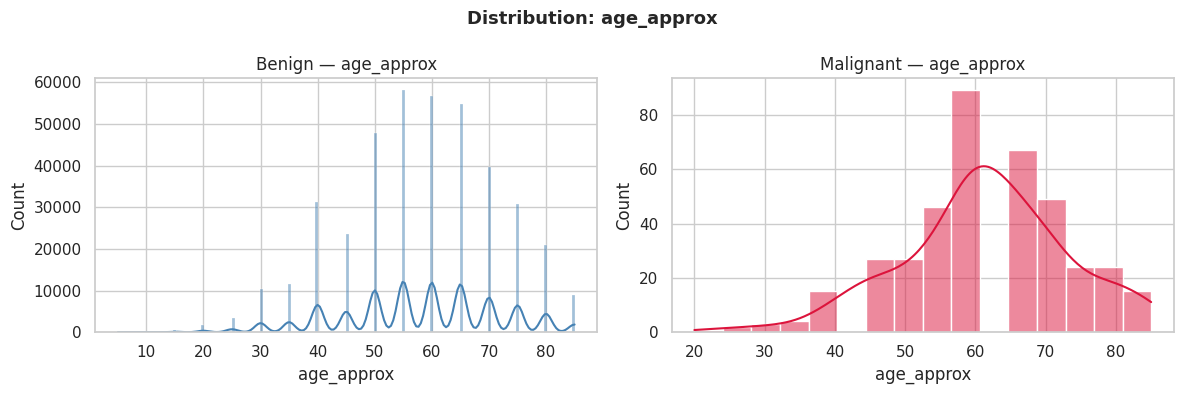

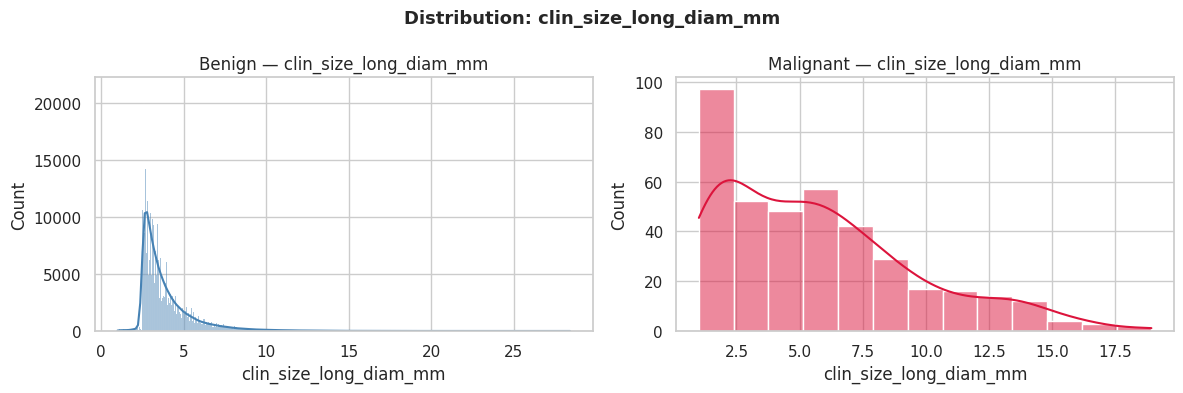

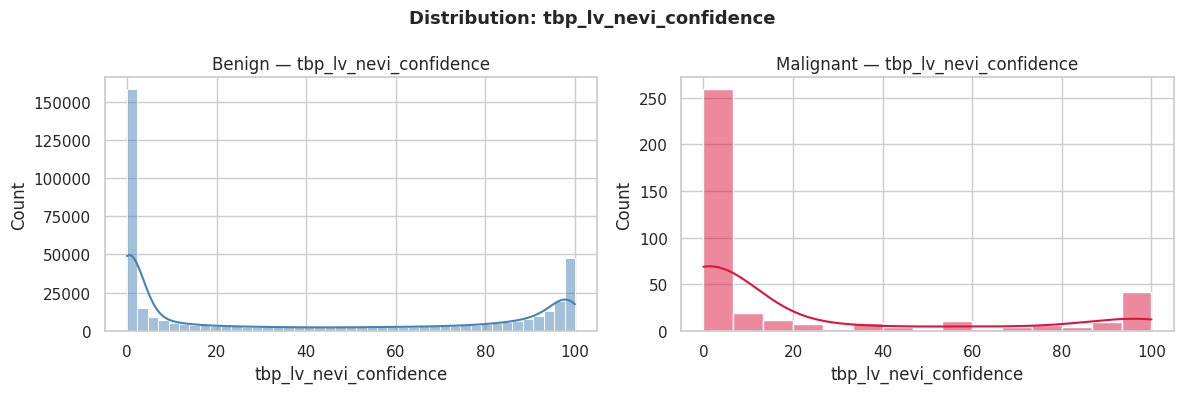

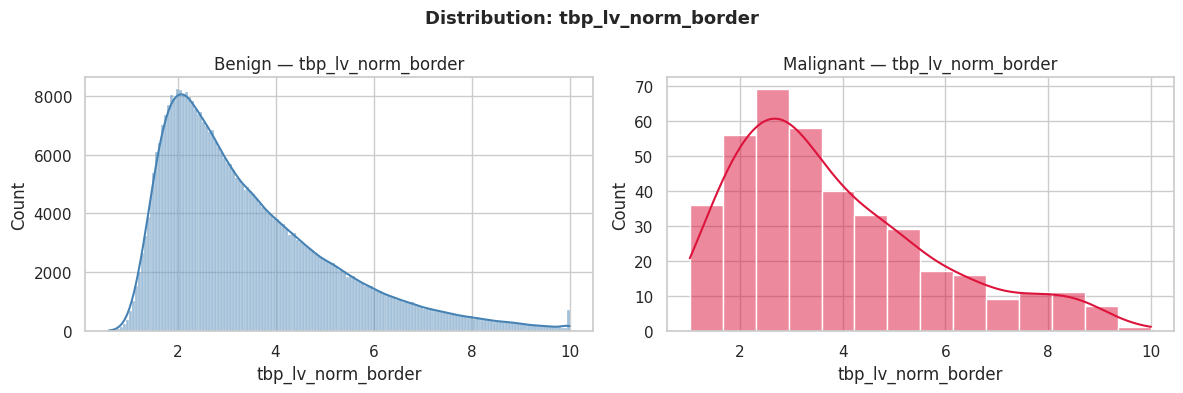

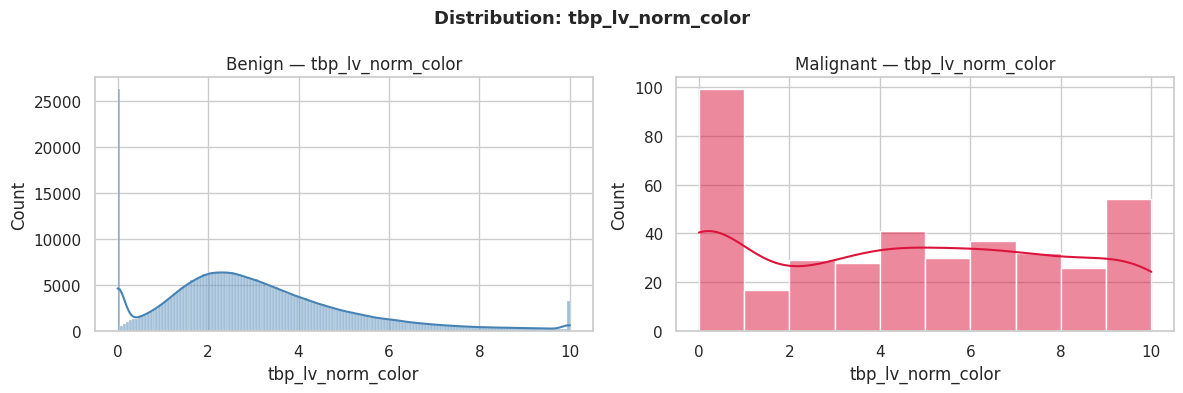

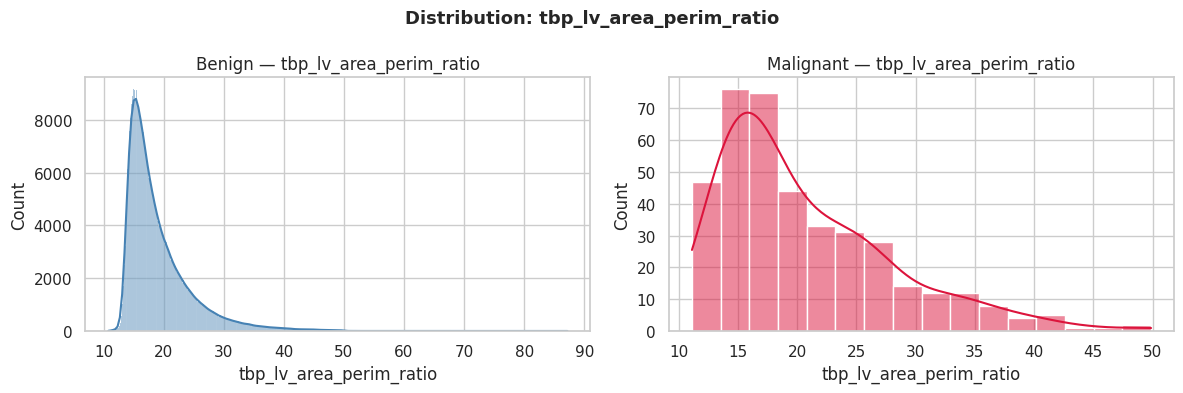

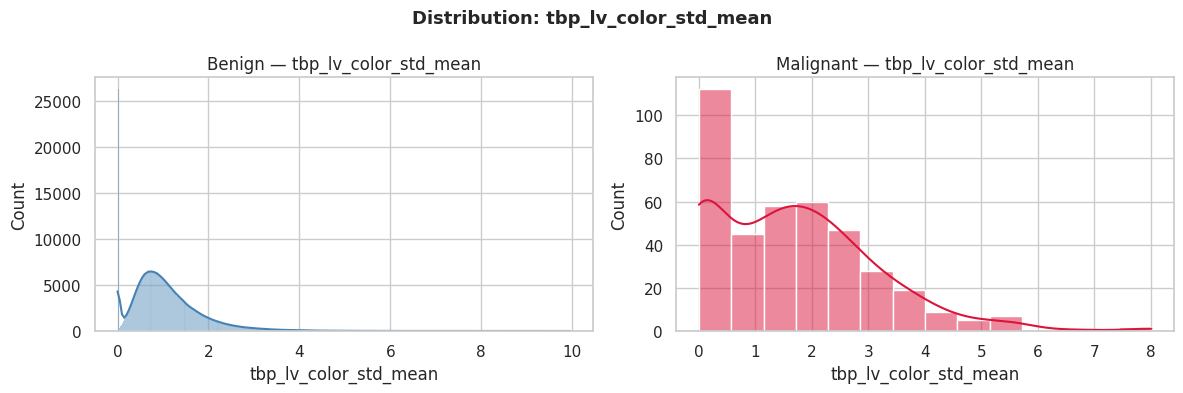

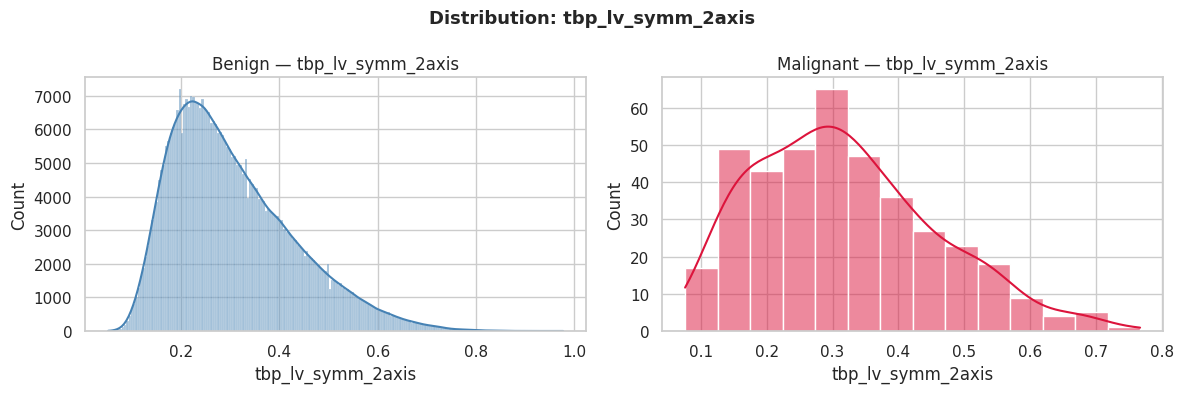

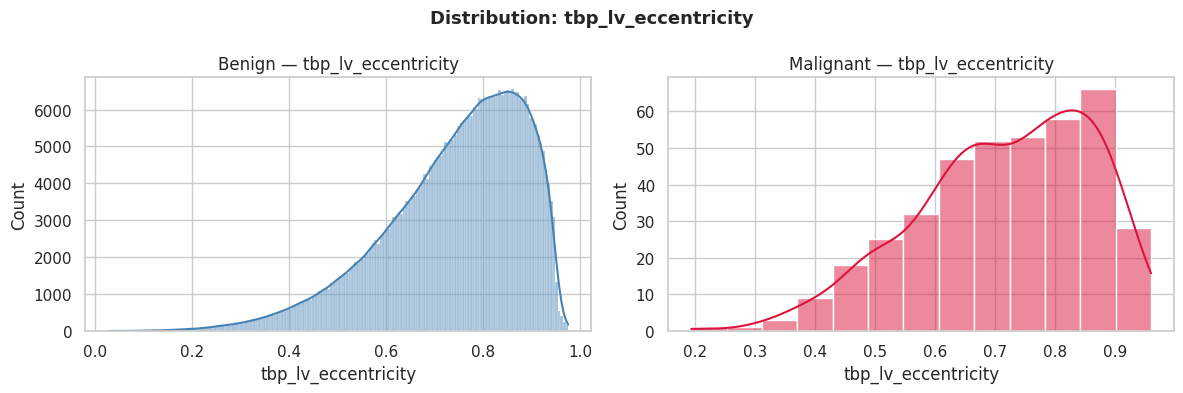

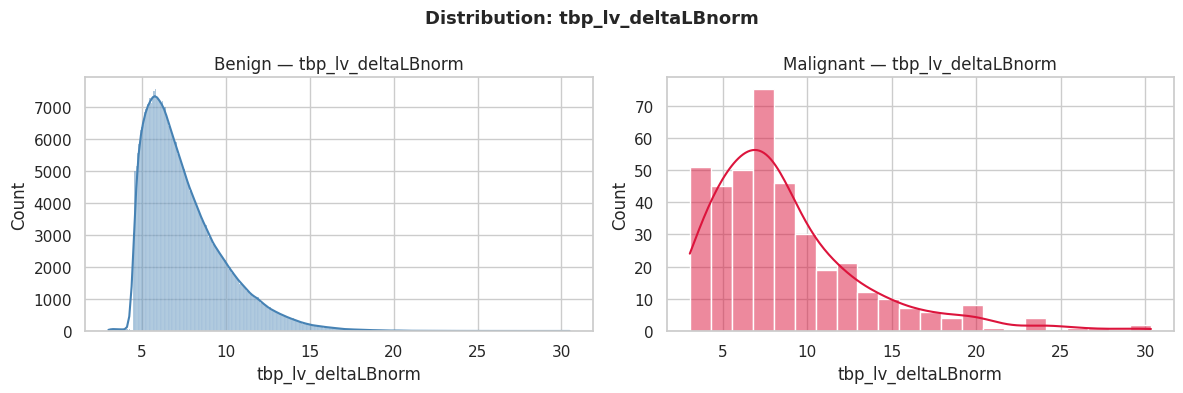

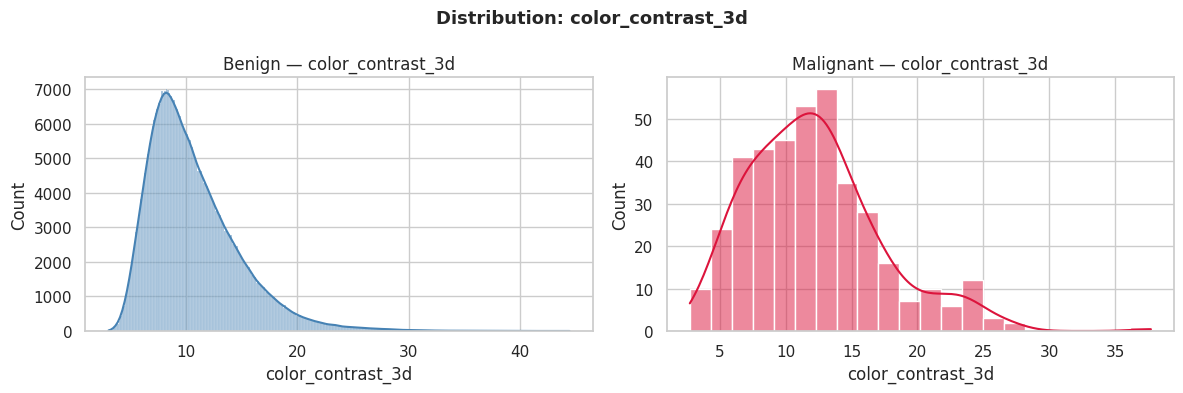

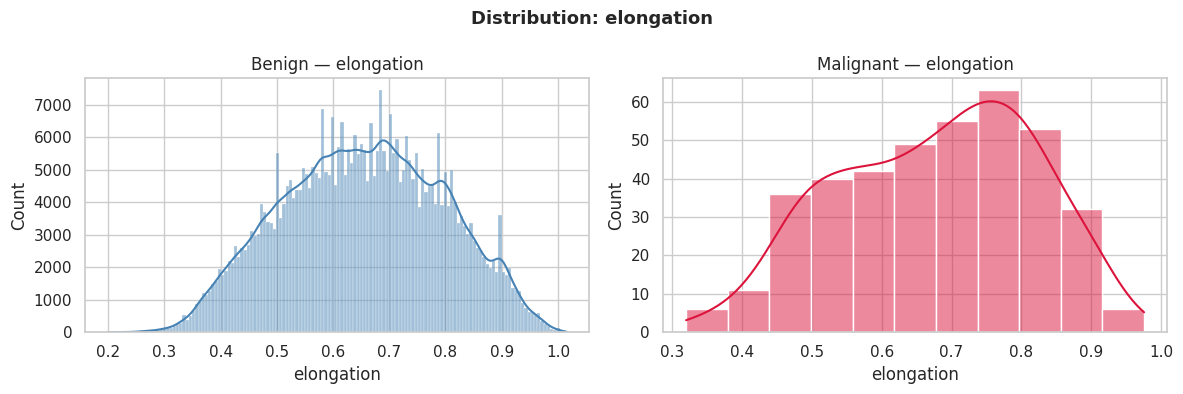

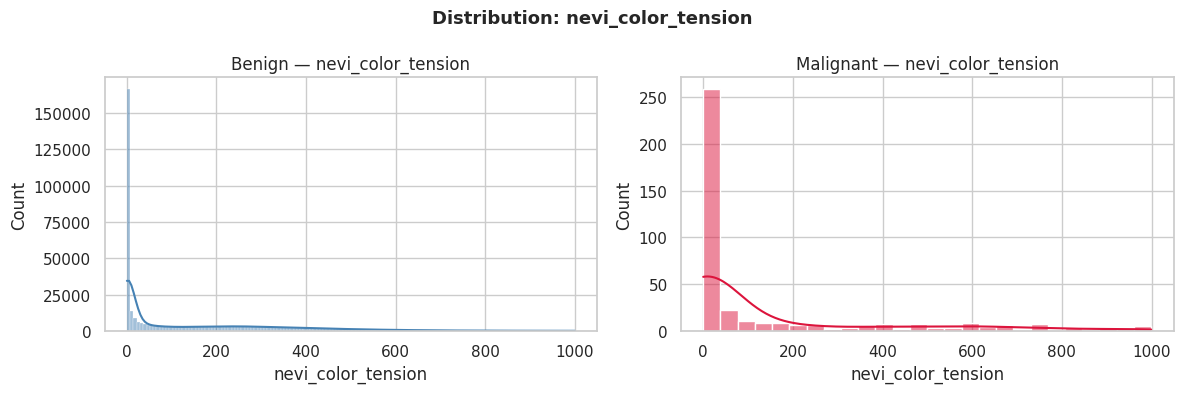

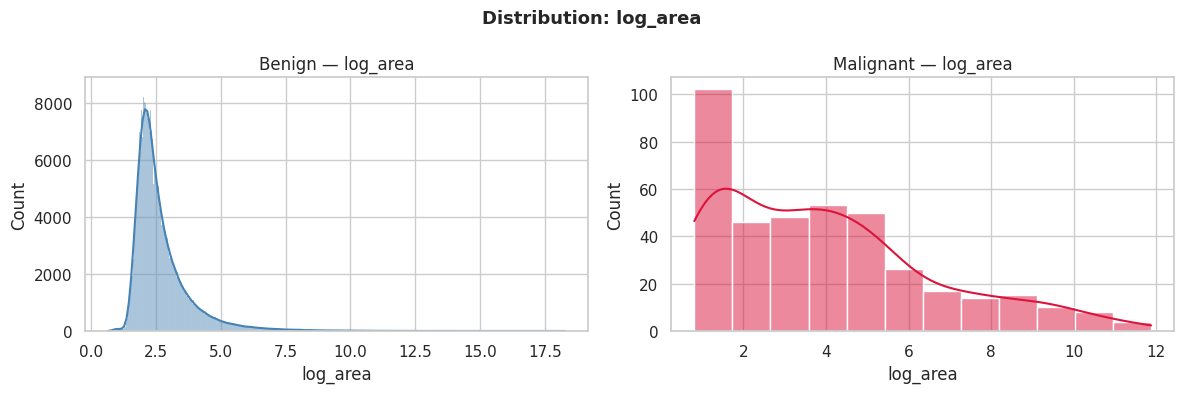

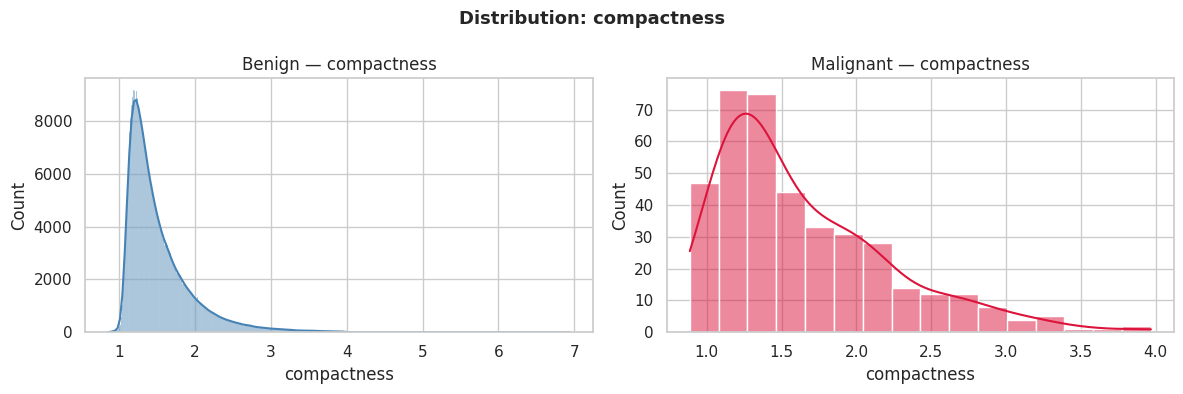

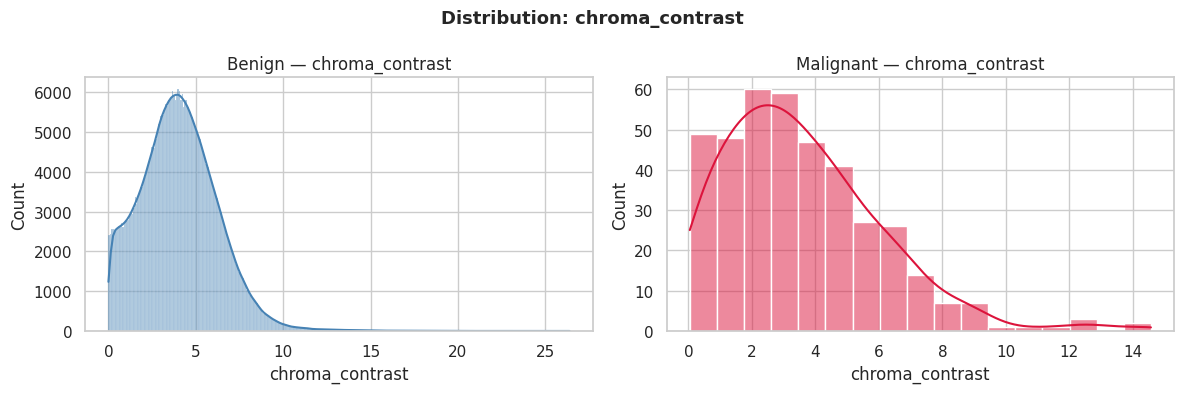

All histograms saved!


In [16]:
for col in ANALYSIS_COLS:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(df_benign[col], kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title(f'Benign — {col}')
    axes[0].set_xlabel(col)

    sns.histplot(df_malignant[col], kde=True, ax=axes[1], color='crimson')
    axes[1].set_title(f'Malignant — {col}')
    axes[1].set_xlabel(col)

    plt.suptitle(f'Distribution: {col}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(SAVE_DIR / f'{col}_histogram.png', dpi=150, bbox_inches='tight')
    plt.show()

print("All histograms saved!")

## Step 14b — Box Plots (Benign vs Malignant per Feature)

Box plots show the median, interquartile range, and outliers
for each feature side by side between benign and malignant groups.
This makes it easy to see if the two groups have different central tendencies.

/tmp/ipykernel_38047/1787617963.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Class', y=col,


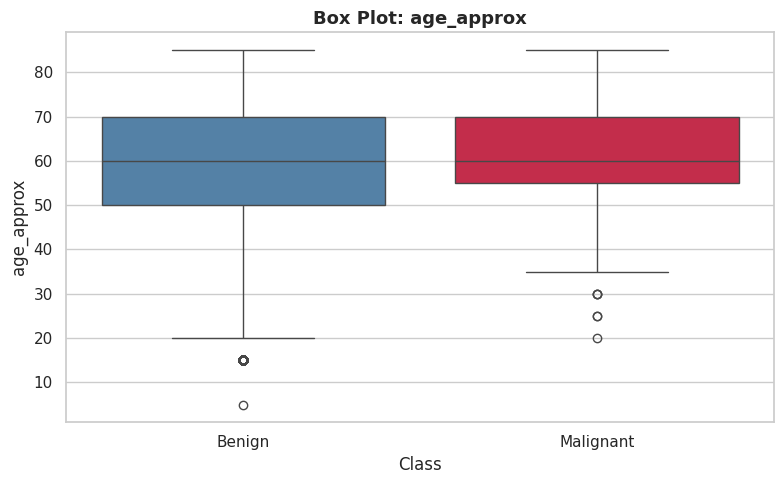

/tmp/ipykernel_38047/1787617963.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Class', y=col,


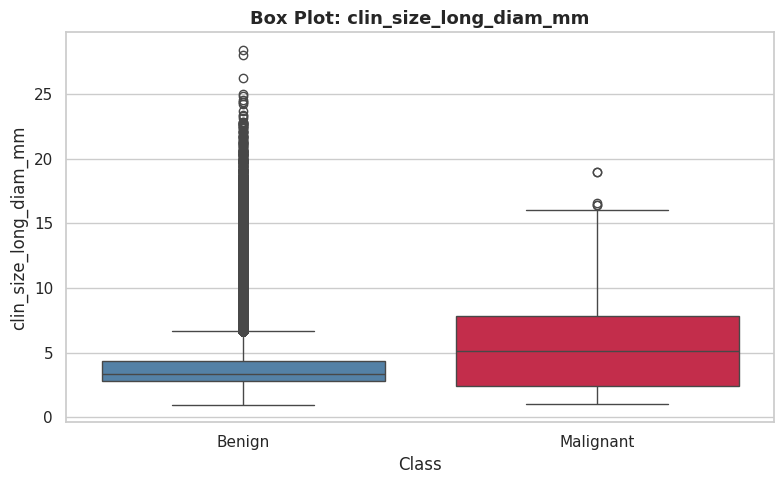

/tmp/ipykernel_38047/1787617963.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Class', y=col,


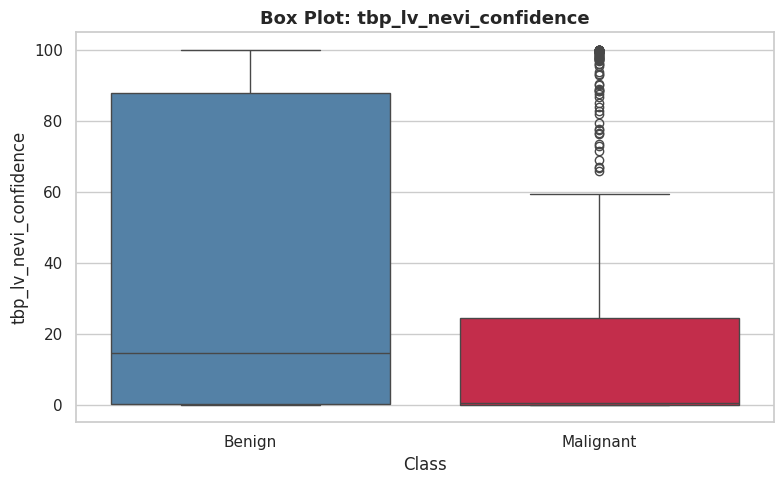

/tmp/ipykernel_38047/1787617963.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Class', y=col,


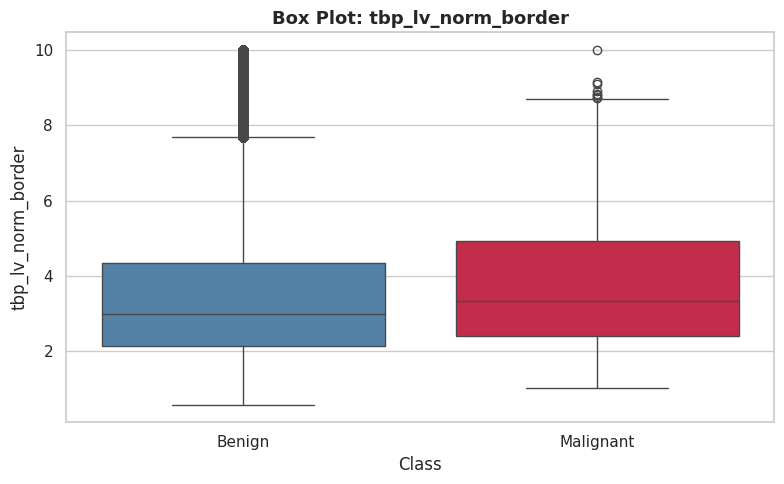

/tmp/ipykernel_38047/1787617963.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Class', y=col,


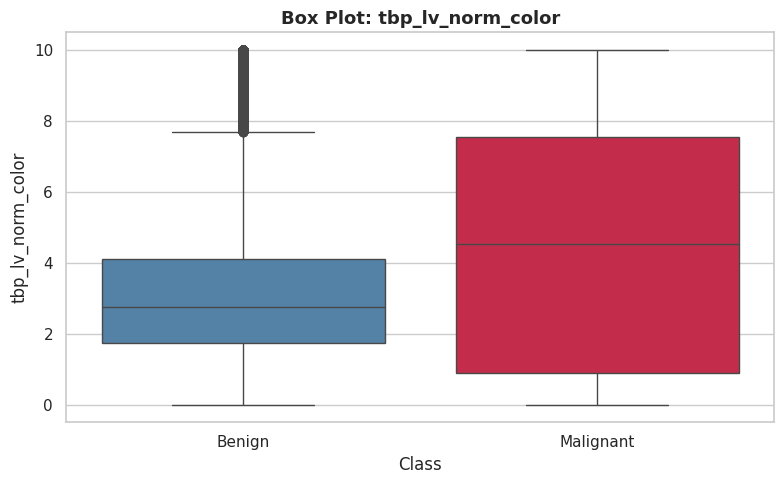

/tmp/ipykernel_38047/1787617963.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Class', y=col,


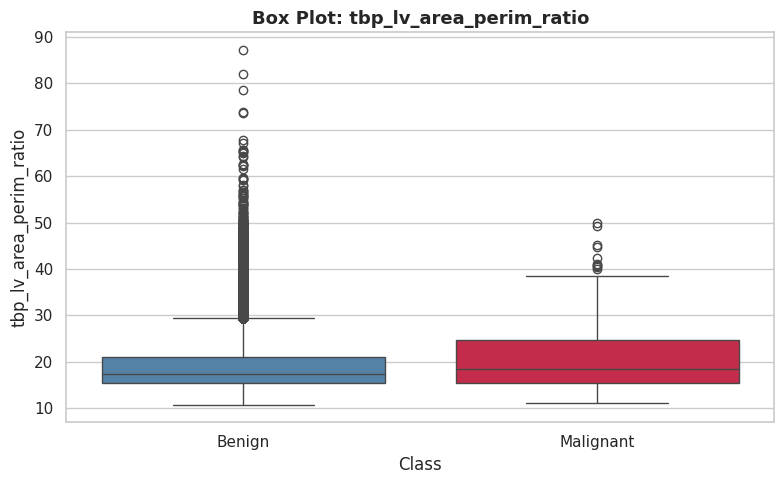

/tmp/ipykernel_38047/1787617963.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Class', y=col,


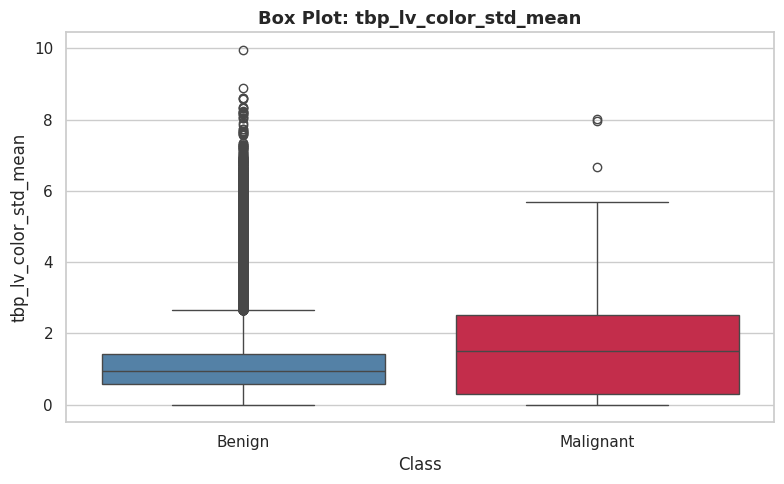

/tmp/ipykernel_38047/1787617963.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Class', y=col,


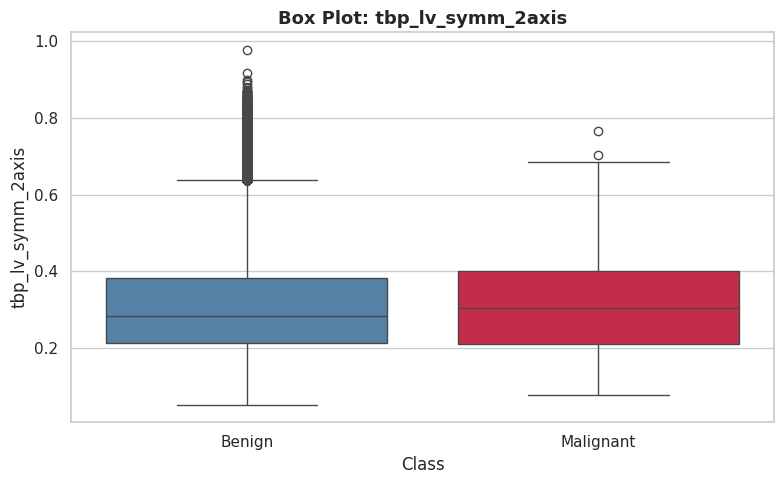

/tmp/ipykernel_38047/1787617963.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Class', y=col,


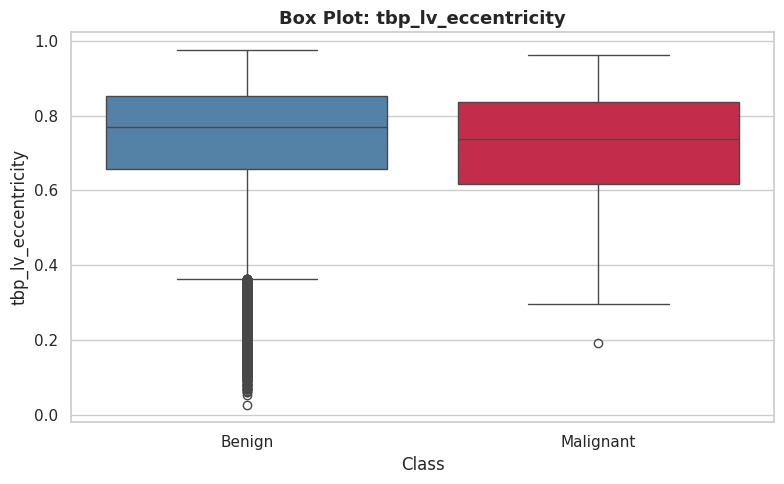

/tmp/ipykernel_38047/1787617963.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Class', y=col,


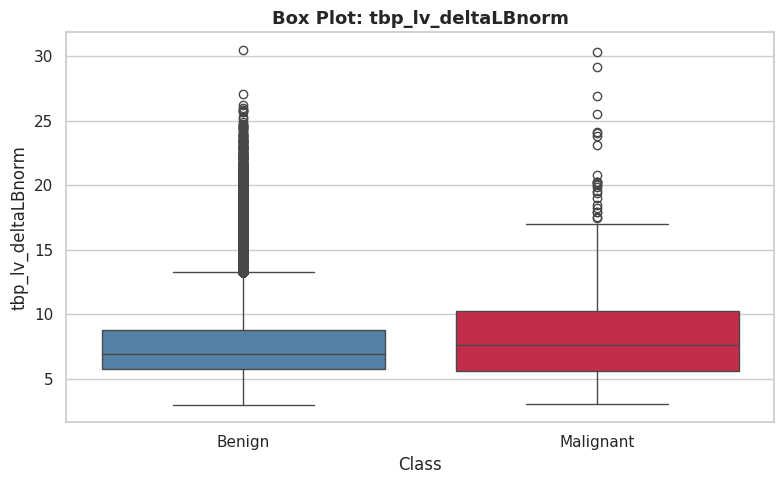

/tmp/ipykernel_38047/1787617963.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Class', y=col,


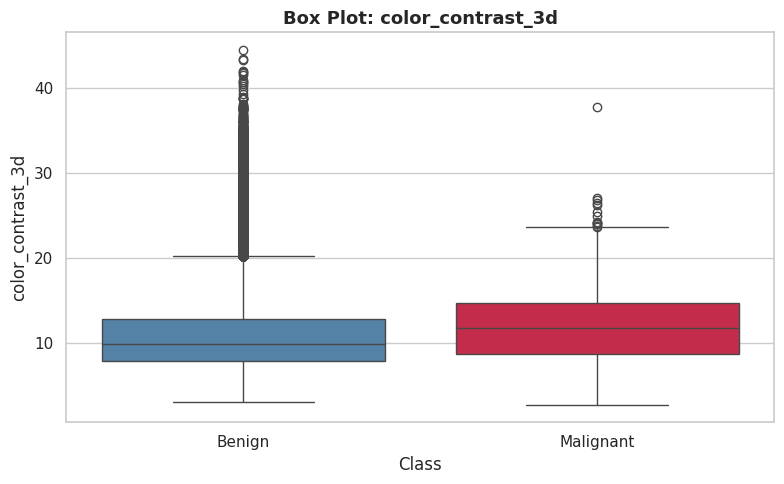

/tmp/ipykernel_38047/1787617963.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Class', y=col,


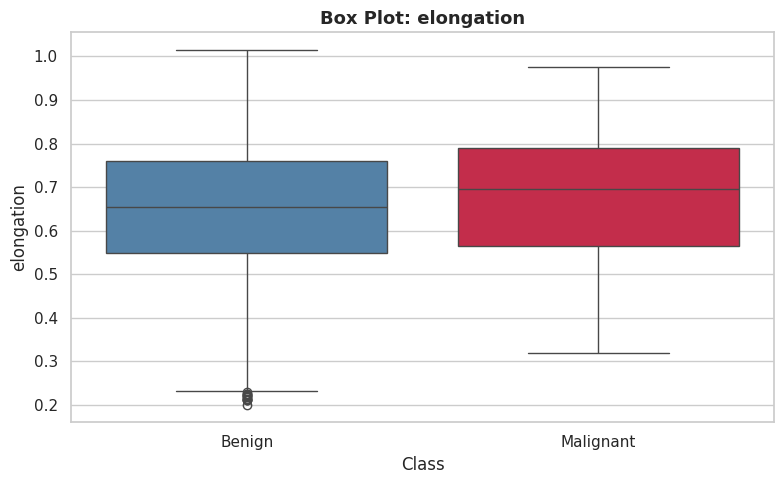

/tmp/ipykernel_38047/1787617963.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Class', y=col,


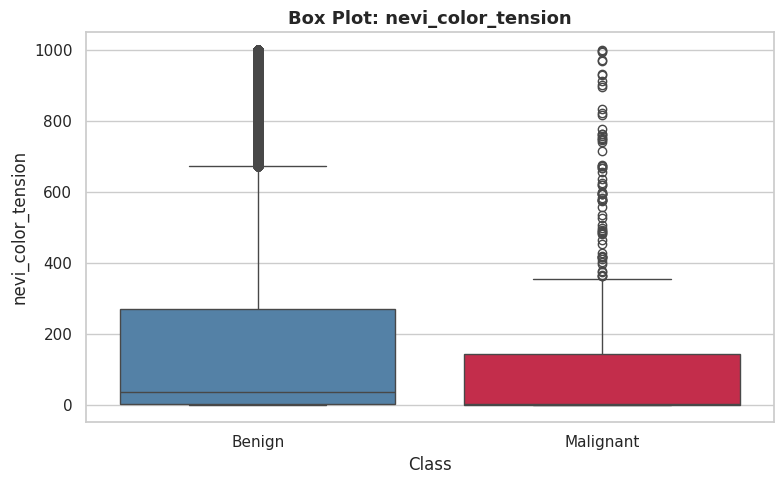

/tmp/ipykernel_38047/1787617963.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Class', y=col,


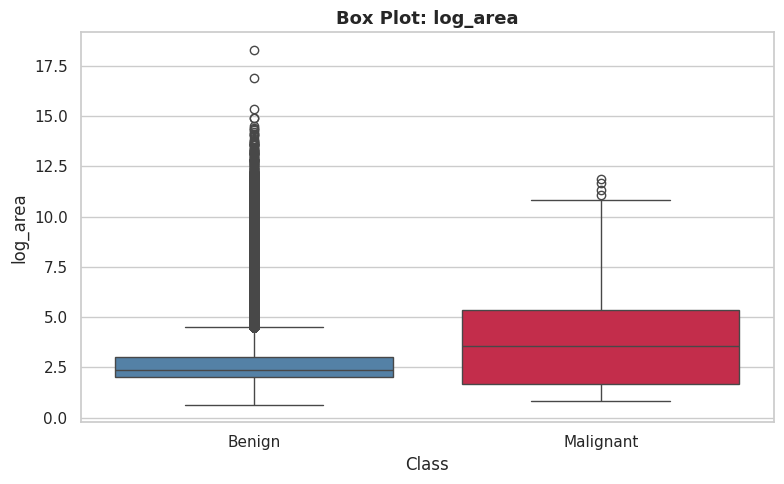

/tmp/ipykernel_38047/1787617963.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Class', y=col,


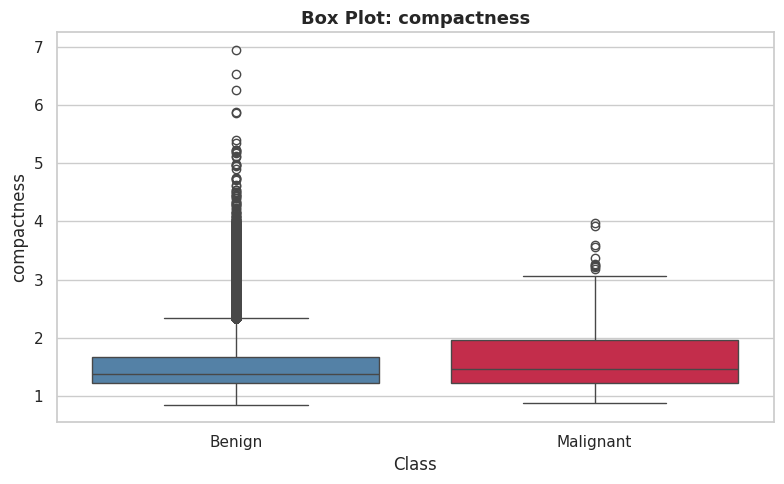

/tmp/ipykernel_38047/1787617963.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Class', y=col,


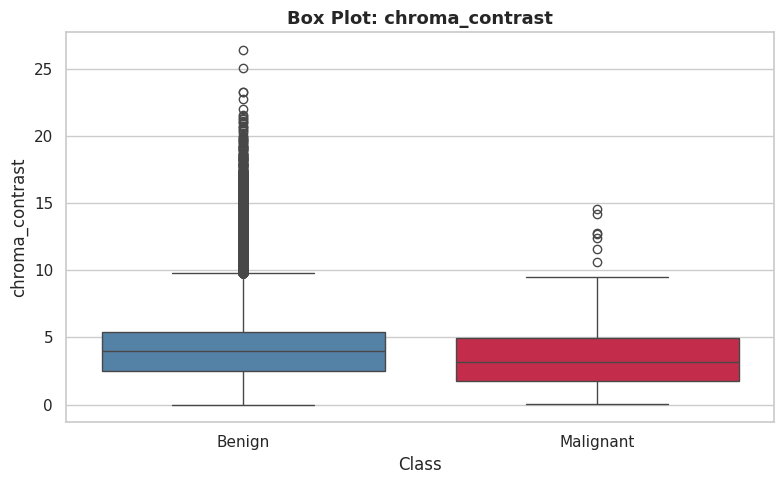

All box plots saved!


In [17]:
for col in ANALYSIS_COLS:
    fig, ax = plt.subplots(figsize=(8, 5))

    df_plot = df[['malignant', col]].copy()
    df_plot['Class'] = df_plot['malignant'].map({0: 'Benign', 1: 'Malignant'})

    sns.boxplot(data=df_plot, x='Class', y=col,
                palette={'Benign': 'steelblue', 'Malignant': 'crimson'}, ax=ax)

    ax.set_title(f'Box Plot: {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Class')
    ax.set_ylabel(col)

    plt.tight_layout()
    plt.savefig(SAVE_DIR / f'{col}_boxplot.png', dpi=150, bbox_inches='tight')
    plt.show()

print("All box plots saved!")

## Step 14c — Bar Charts (Low / Medium / High Bin Distribution)

For each feature we show what percentage of benign vs malignant records
fall into the Low, Medium, and High bins.
This directly visualizes the feature range table we computed earlier.

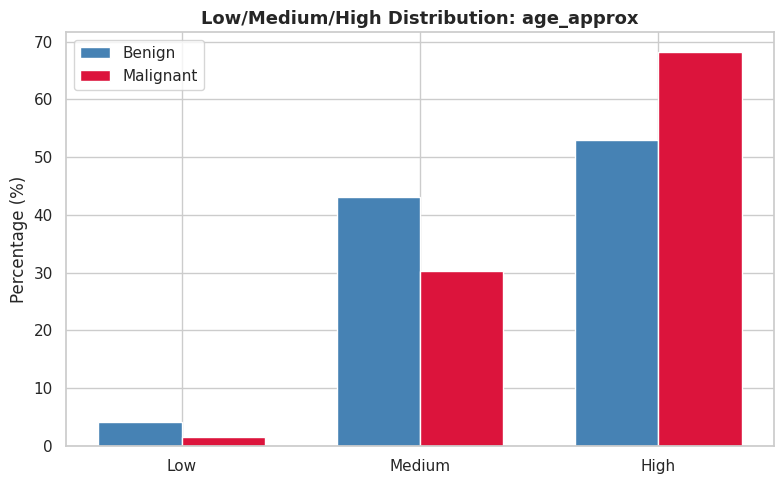

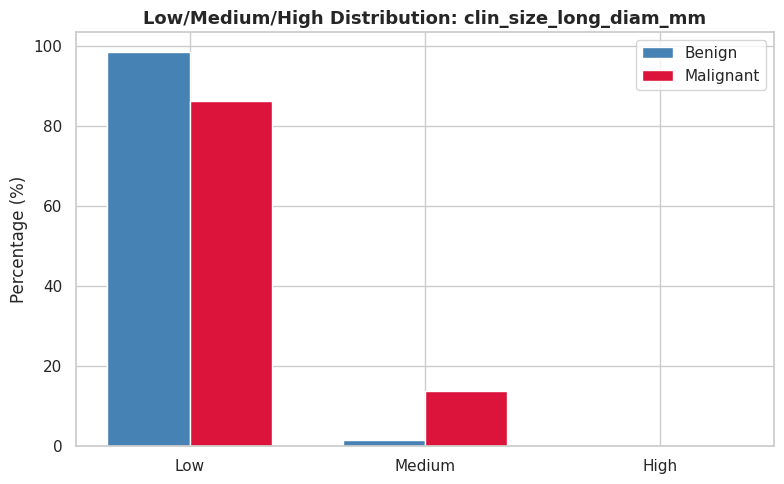

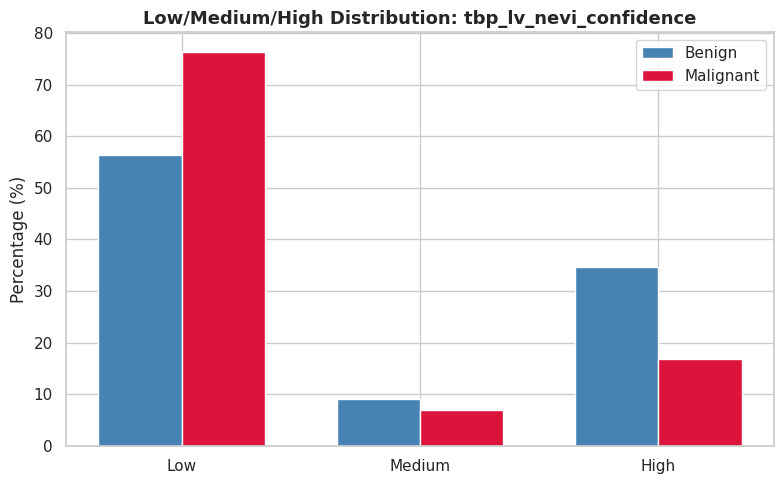

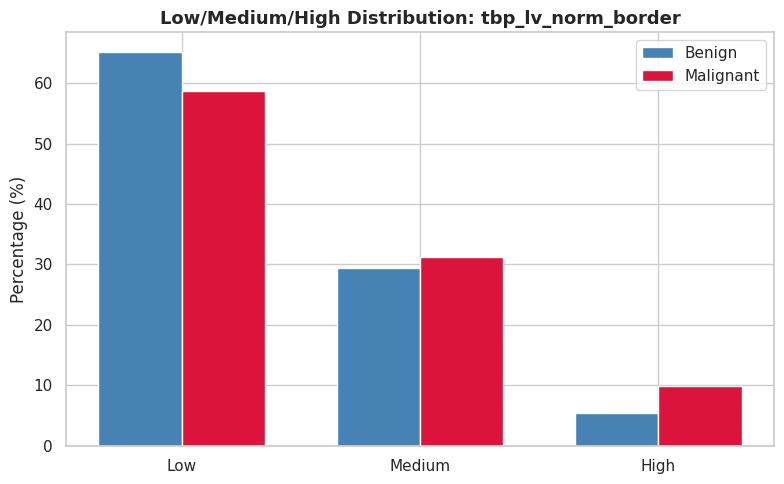

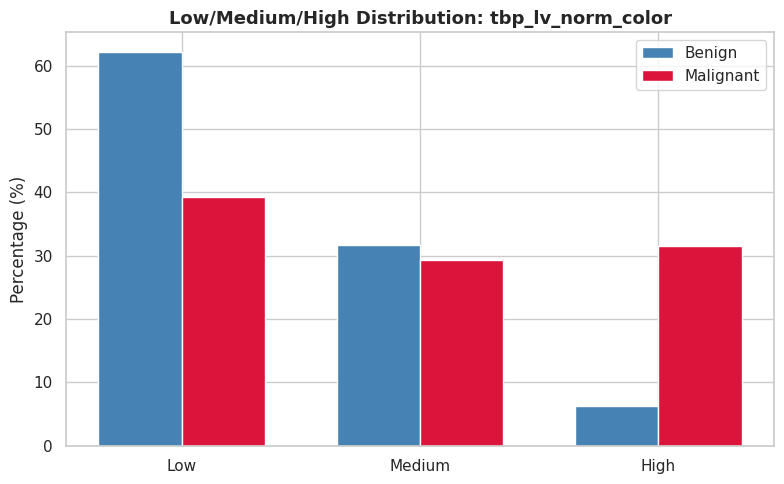

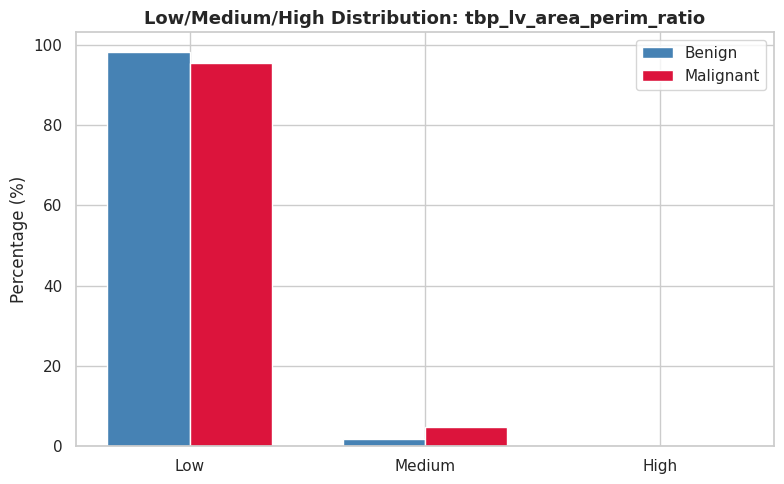

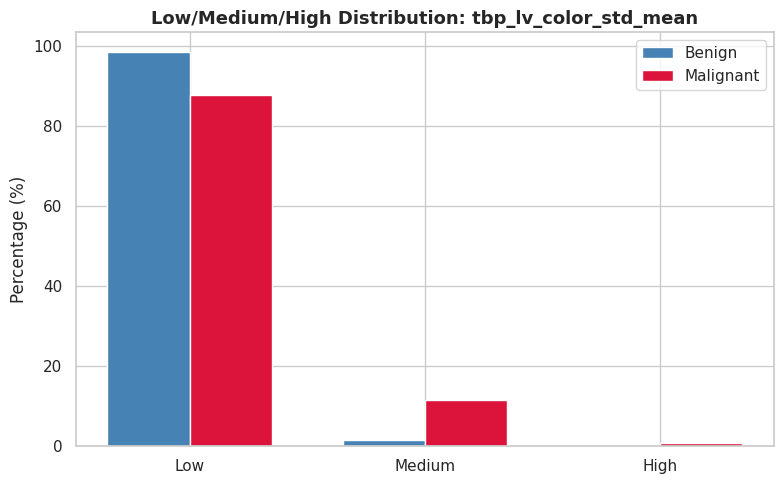

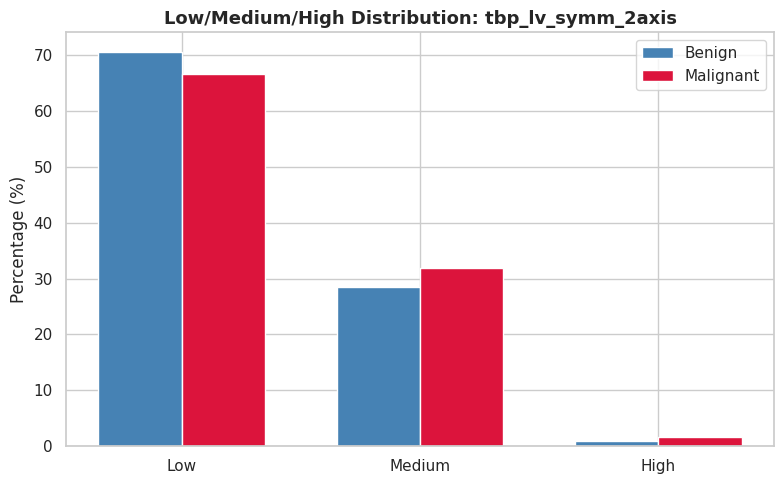

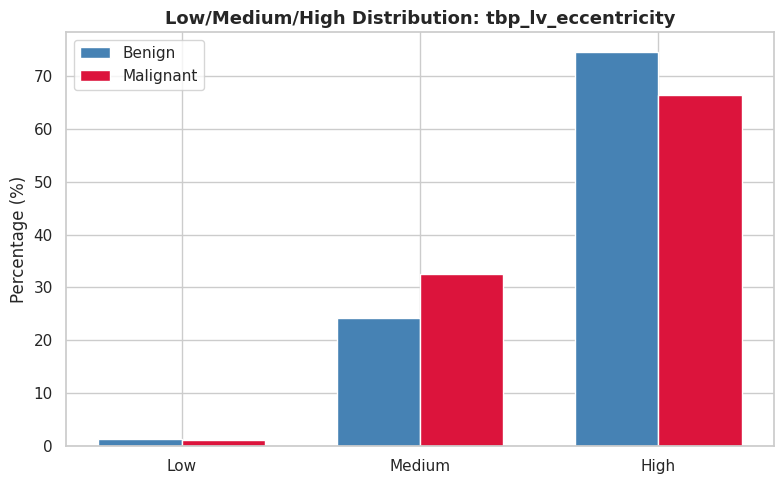

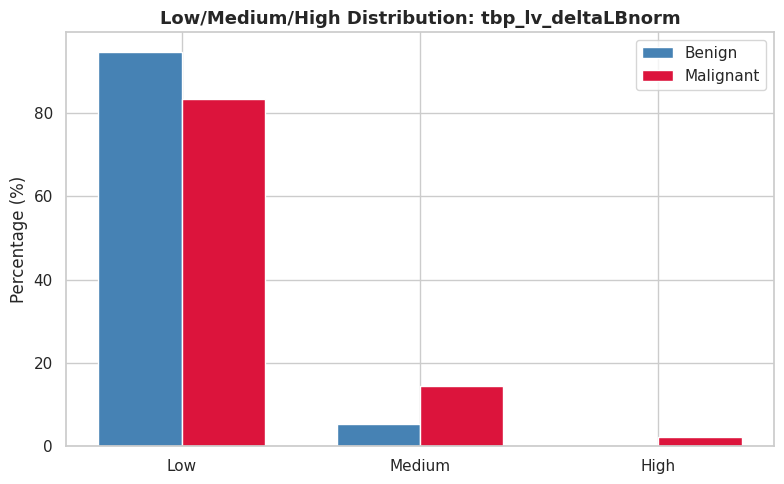

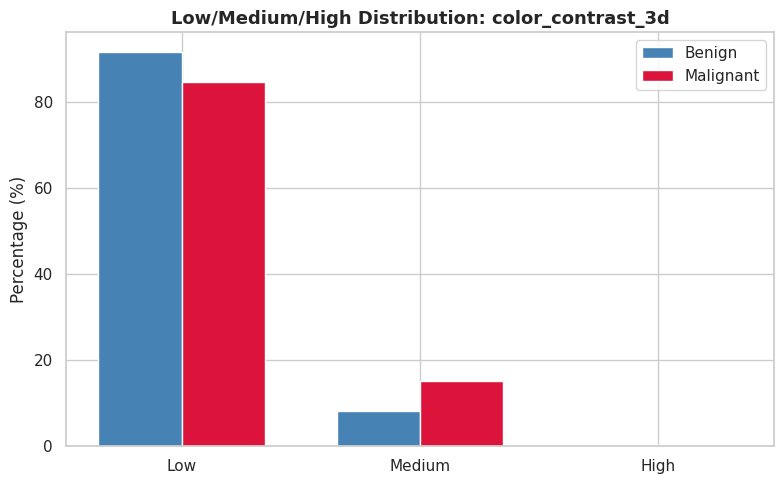

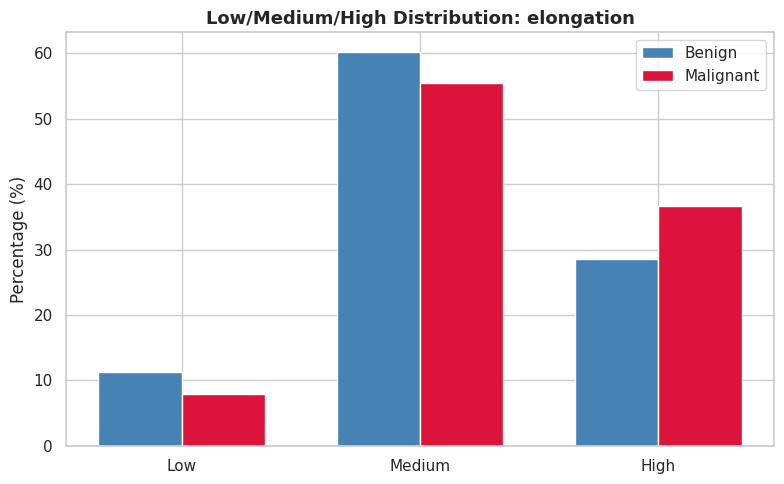

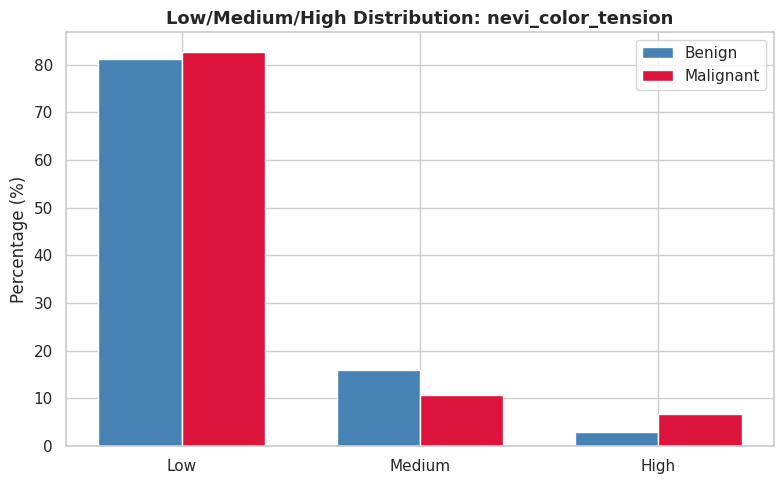

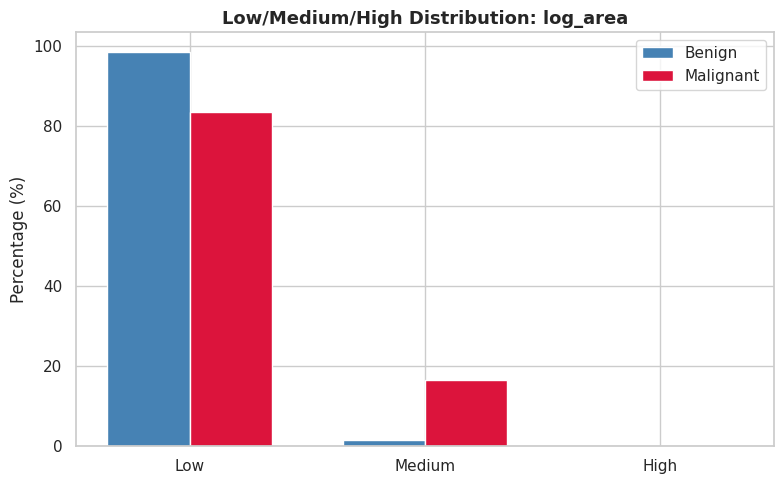

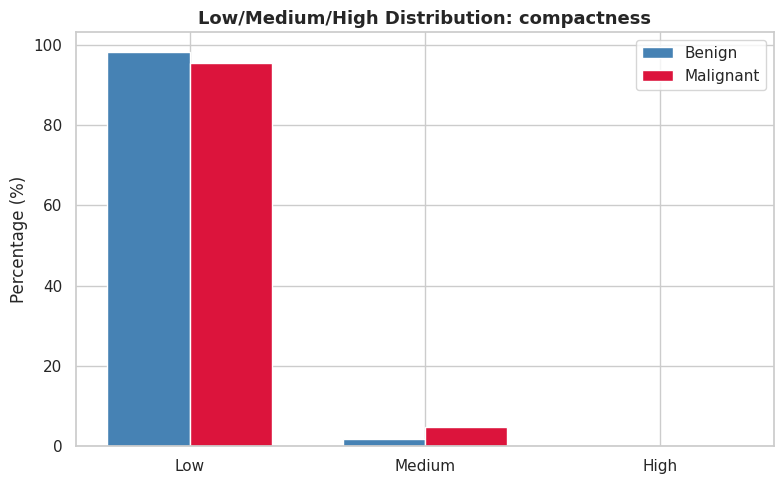

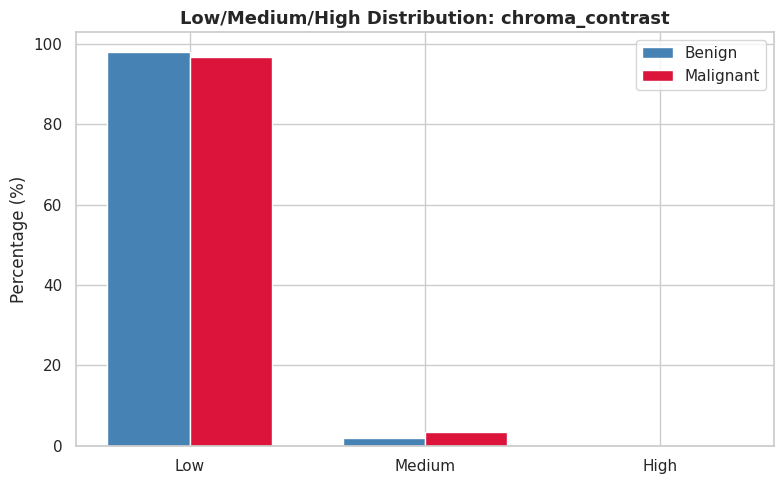

All bar charts saved!


In [18]:
for _, row in df_ranges.iterrows():
    col = row['feature']

    categories = ['Low', 'Medium', 'High']
    benign_vals    = [row['benign_low_%'], row['benign_medium_%'], row['benign_high_%']]
    malignant_vals = [row['malignant_low_%'], row['malignant_medium_%'], row['malignant_high_%']]

    x = range(len(categories))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar([i - width/2 for i in x], benign_vals,    width, label='Benign',    color='steelblue')
    ax.bar([i + width/2 for i in x], malignant_vals, width, label='Malignant', color='crimson')

    ax.set_title(f'Low/Medium/High Distribution: {col}', fontsize=13, fontweight='bold')
    ax.set_xticks(list(x))
    ax.set_xticklabels(categories)
    ax.set_ylabel('Percentage (%)')
    ax.legend()

    plt.tight_layout()
    plt.savefig(SAVE_DIR / f'{col}_barchart.png', dpi=150, bbox_inches='tight')
    plt.show()

print("All bar charts saved!")

## Step 14d — Pie Charts (Categorical Features)

For sex, anatomical site, and location we show pie charts
comparing the proportion of each category between benign and malignant groups.

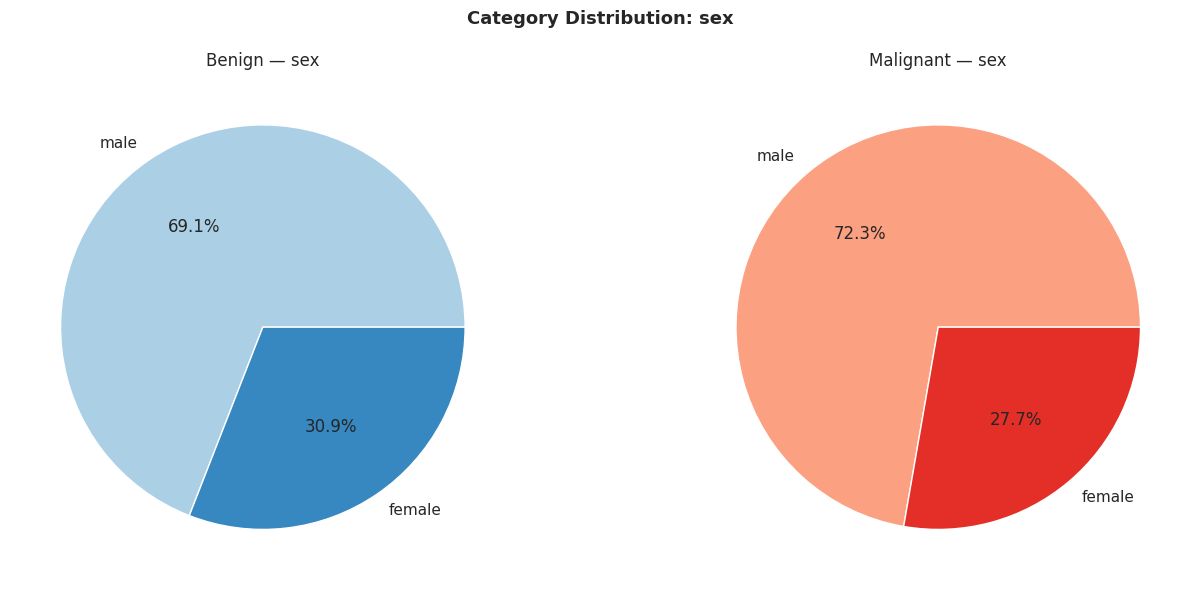

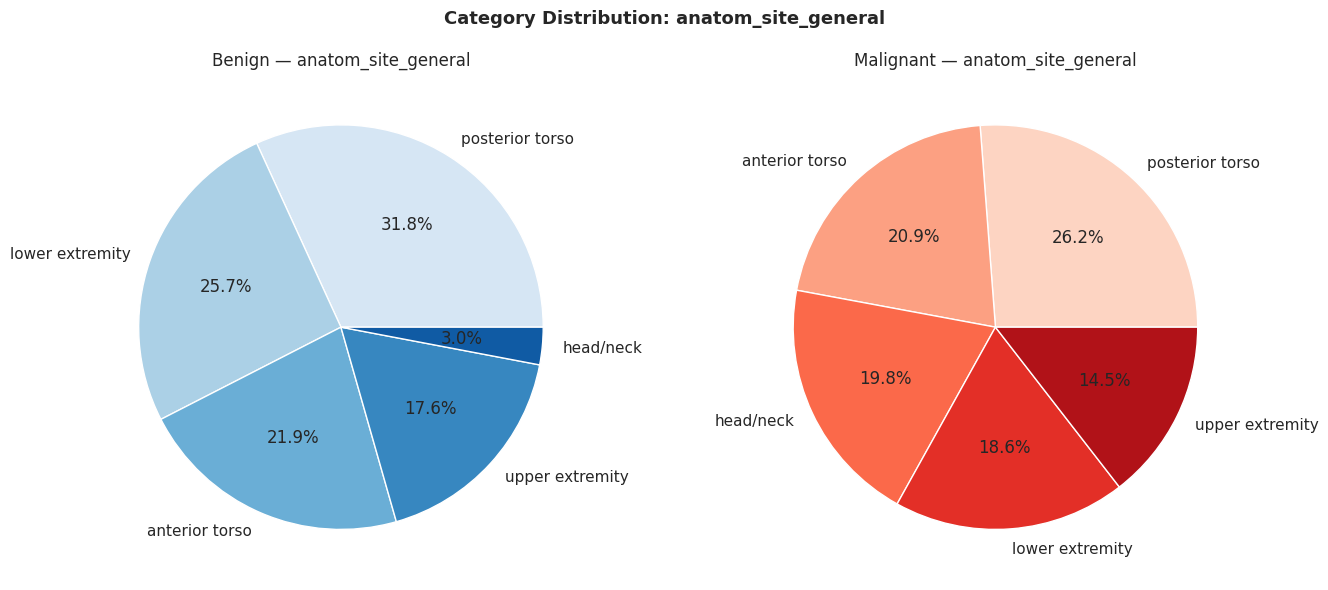

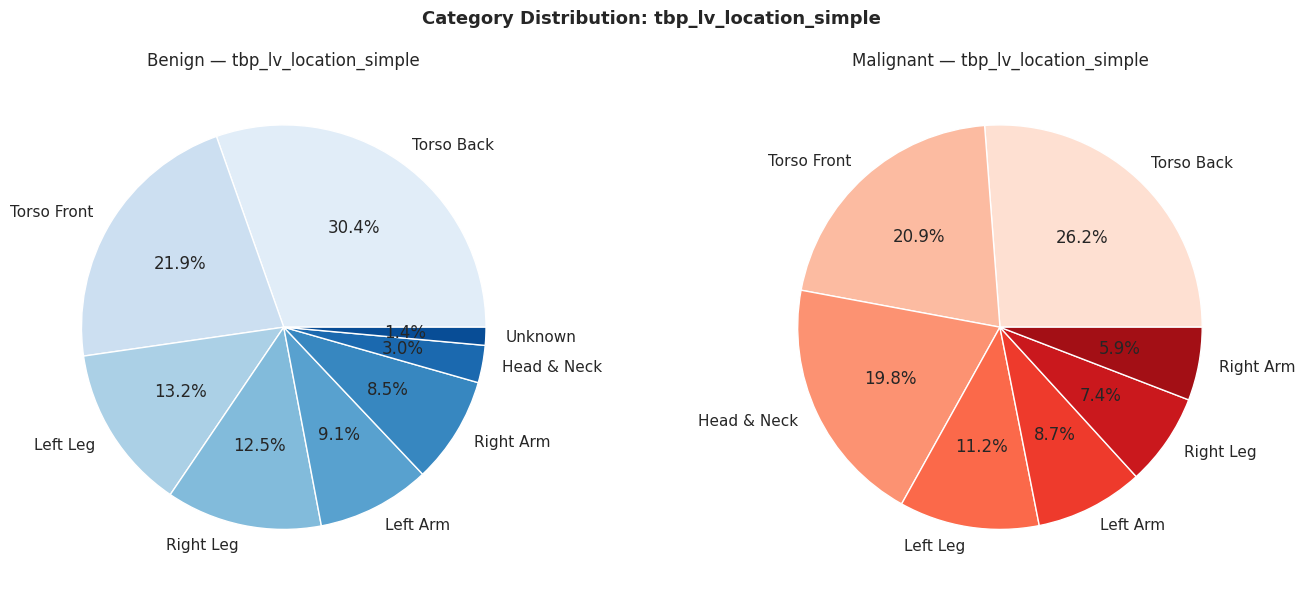

All pie charts saved!


In [19]:
CAT_COLS = ['sex', 'anatom_site_general', 'tbp_lv_location_simple']

for col in CAT_COLS:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    df_benign[col].value_counts().plot.pie(
        ax=axes[0], autopct='%1.1f%%',
        title=f'Benign — {col}',
        colors=sns.color_palette('Blues', df_benign[col].nunique())
    )
    axes[0].set_ylabel('')

    df_malignant[col].value_counts().plot.pie(
        ax=axes[1], autopct='%1.1f%%',
        title=f'Malignant — {col}',
        colors=sns.color_palette('Reds', df_malignant[col].nunique())
    )
    axes[1].set_ylabel('')

    plt.suptitle(f'Category Distribution: {col}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(SAVE_DIR / f'{col}_piechart.png', dpi=150, bbox_inches='tight')
    plt.show()

print("All pie charts saved!")

## Step 14e — Correlation Heatmap

The correlation heatmap shows how strongly each pair of features
moves together across all records.
Features that correlate strongly with each other may be redundant.
Features that don't correlate are providing unique information.

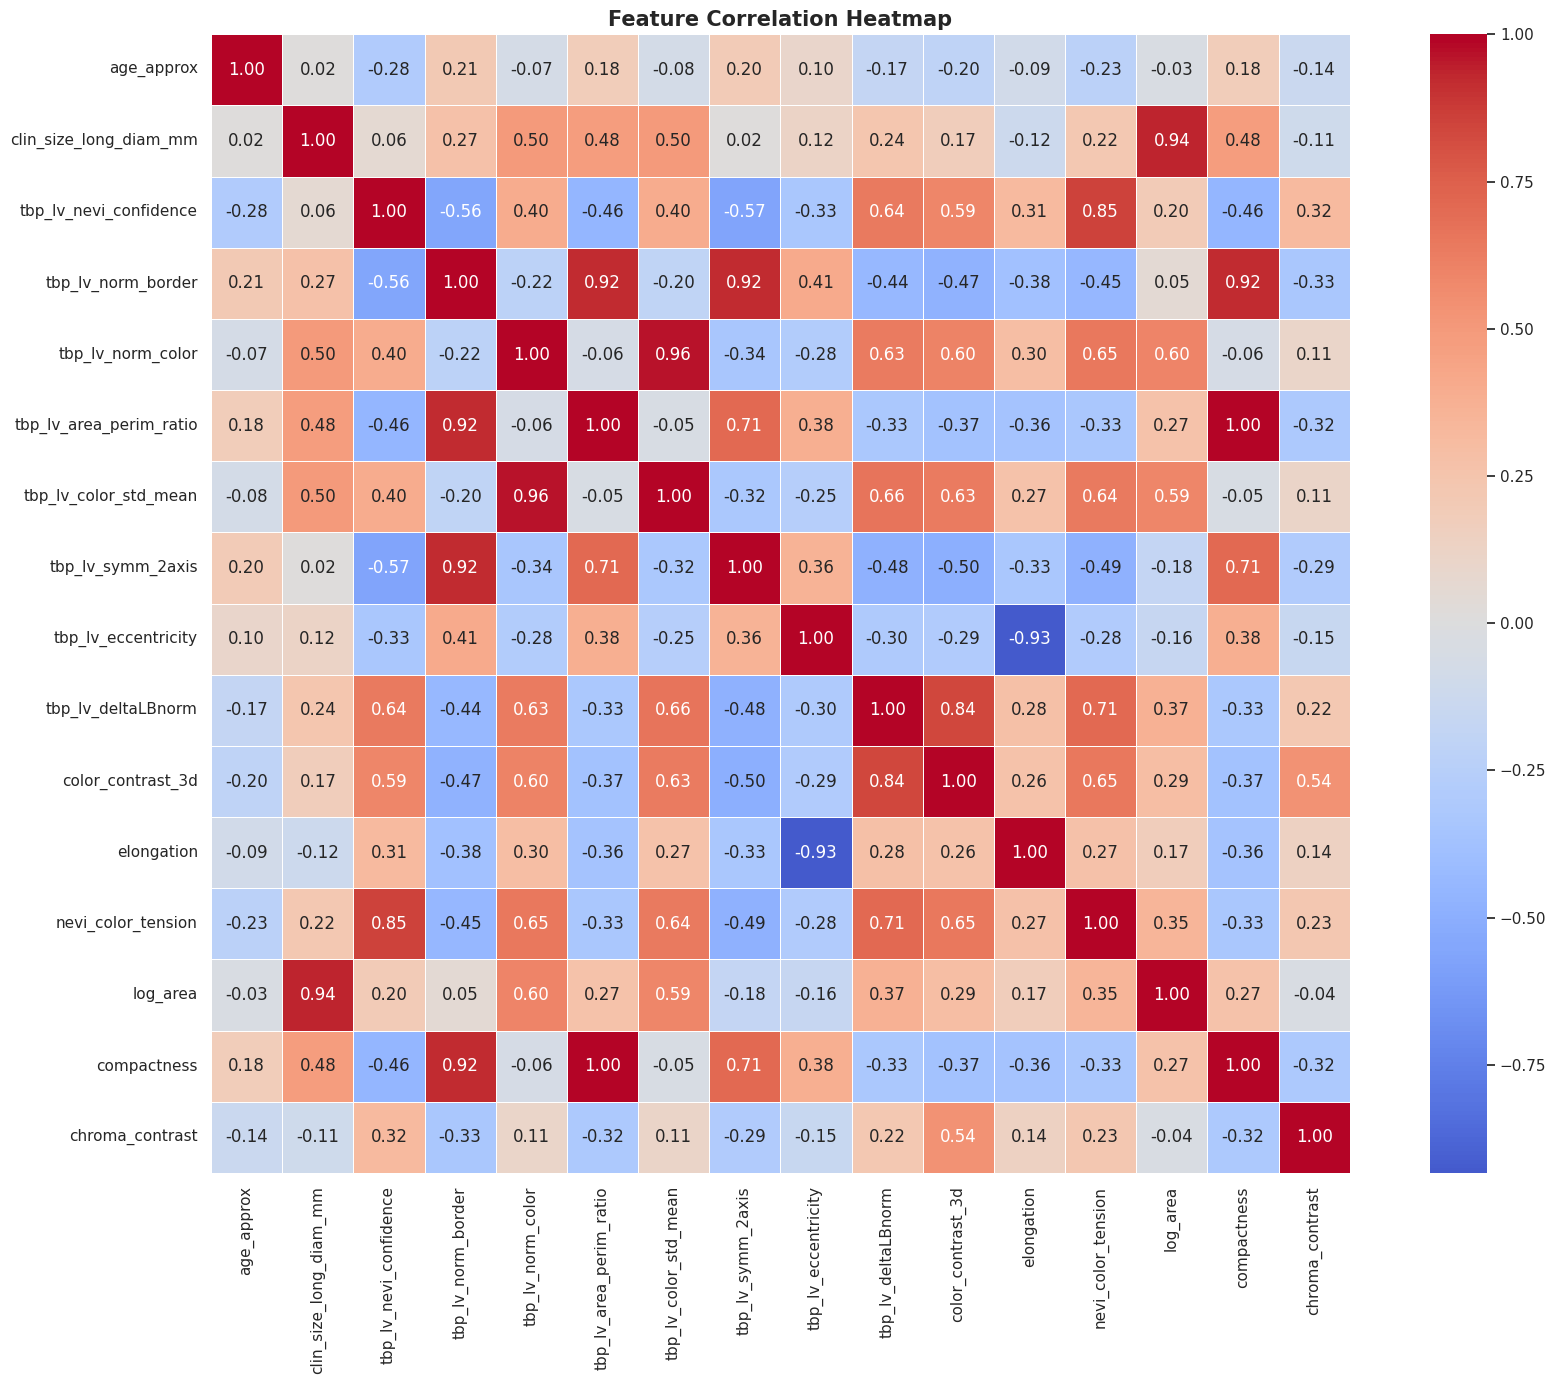

Correlation heatmap saved!


In [20]:
fig, ax = plt.subplots(figsize=(18, 14))

corr_matrix = df[ANALYSIS_COLS].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Correlation heatmap saved!")

## Step 14f — Risk Score Distribution

Finally we visualize how the risk scores are distributed across all benign records.
This is the summary chart of our core output.

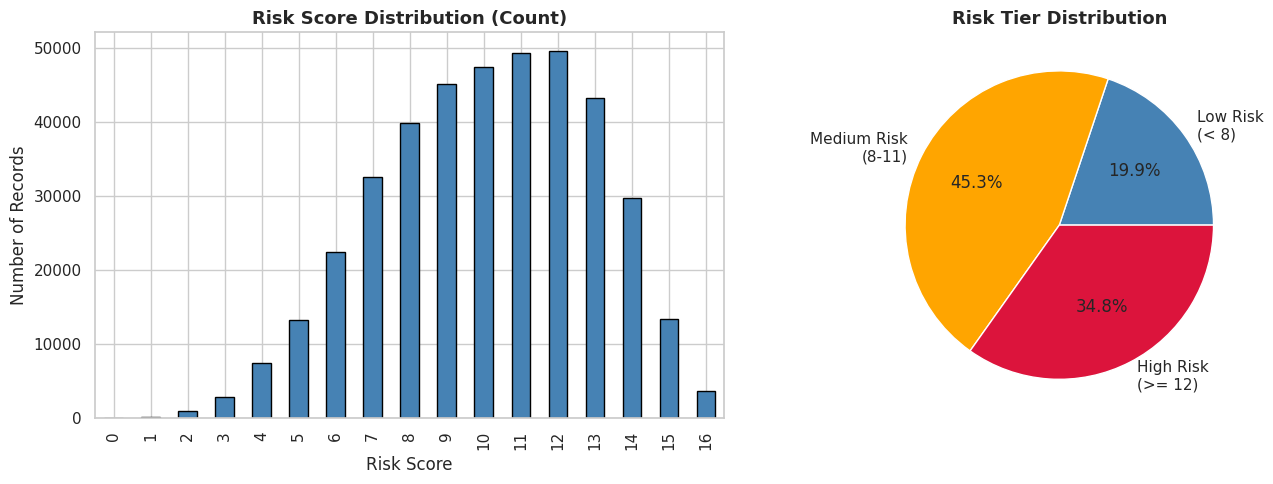

Risk score distribution saved!

All graphs saved to: /home/xcane/dev/ml/170melanoma/outputs/graphs


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_benign['risk_score'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('Risk Score Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Risk Score')
axes[0].set_ylabel('Number of Records')

tier_counts = [
    (df_benign['risk_score'] < 8).sum(),
    ((df_benign['risk_score'] >= 8) & (df_benign['risk_score'] < 12)).sum(),
    (df_benign['risk_score'] >= 12).sum()
]
tier_labels = ['Low Risk\n(< 8)', 'Medium Risk\n(8-11)', 'High Risk\n(>= 12)']
axes[1].pie(tier_counts, labels=tier_labels, autopct='%1.1f%%',
            colors=['steelblue', 'orange', 'crimson'])
axes[1].set_title('Risk Tier Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(SAVE_DIR / 'risk_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Risk score distribution saved!")
print(f"\nAll graphs saved to: {SAVE_DIR}")

## Step 15 — Statistical Tests (Mann-Whitney U)

We run a Mann-Whitney U test for every feature to formally confirm
which features are statistically different between benign and malignant groups.

Unlike a t-test, Mann-Whitney U does not assume normal distribution —
making it more suitable for clinical measurements like these.

- p-value < 0.05 = the feature is statistically significantly different between groups
- The smaller the p-value, the stronger the separation

In [22]:
from scipy.stats import mannwhitneyu

mw_results = []

for col in ANALYSIS_COLS:
    stat, p = mannwhitneyu(
        df_malignant[col].dropna(),
        df_benign[col].dropna(),
        alternative='two-sided'
    )
    mw_results.append({
        'feature': col,
        'statistic': round(stat, 2),
        'p_value': round(p, 6),
        'significant': 'Yes' if p < 0.05 else 'No'
    })

df_mw = pd.DataFrame(mw_results).sort_values('p_value')
print("=== MANN-WHITNEY U TEST RESULTS ===")
print(df_mw.to_string(index=False))

df_mw.to_csv(RESULTS_DIR / 'mann_whitney_results.csv', index=False)
print("\nmann_whitney_results.csv saved!")

=== MANN-WHITNEY U TEST RESULTS ===
                feature  statistic  p_value significant
 clin_size_long_diam_mm 96113006.0 0.000000         Yes
 tbp_lv_nevi_confidence 55784331.5 0.000000         Yes
  tbp_lv_color_std_mean 96025485.5 0.000000         Yes
      tbp_lv_norm_color 96926573.0 0.000000         Yes
     nevi_color_tension 60867108.0 0.000000         Yes
               log_area 97309871.5 0.000000         Yes
        chroma_contrast 66467237.0 0.000000         Yes
      color_contrast_3d 92631300.0 0.000000         Yes
             age_approx 89807255.5 0.000001         Yes
     tbp_lv_norm_border 87098511.5 0.000265         Yes
    tbp_lv_eccentricity 70419035.0 0.000291         Yes
             elongation 86533530.5 0.000671         Yes
     tbp_lv_deltaLBnorm 86479634.0 0.000731         Yes
tbp_lv_area_perim_ratio 85537394.5 0.003007         Yes
            compactness 85536823.5 0.003009         Yes
      tbp_lv_symm_2axis 82086604.5 0.143521          No

mann_whitne

## Step 16 — Naive Bayes Probability Score

Naive Bayes computes the probability that each record is malignant
given its feature values. We use GaussianNB for continuous features.

This gives every benign record a malignancy probability score —
a second risk measure alongside our IQR-based risk score.
The higher the probability, the more the model thinks the record
resembles a malignant lesion.

In [23]:
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder

# Prepare features — numeric only for GaussianNB
NB_COLS = ANALYSIS_COLS.copy()

X_nb = df[NB_COLS].copy()
y_nb = df['malignant'].copy()

# Train on full dataset
gnb = GaussianNB()
gnb.fit(X_nb, y_nb)

# Get malignancy probability for benign records only
X_benign_nb = df_benign[NB_COLS].copy()
benign_proba = gnb.predict_proba(X_benign_nb)[:, 1]

df_benign = df_benign.copy()
df_benign['malignancy_proba'] = benign_proba

print("=== NAIVE BAYES MALIGNANCY PROBABILITY (Benign Records) ===")
print(f"Probability range: {benign_proba.min():.6f} to {benign_proba.max():.6f}")
print(f"Mean probability: {benign_proba.mean():.6f}")
print(f"\nTop 10 highest probability benign records:")
print(df_benign[['risk_score', 'malignancy_proba'] + ANALYSIS_COLS]
      .sort_values('malignancy_proba', ascending=False).head(10))

=== NAIVE BAYES MALIGNANCY PROBABILITY (Benign Records) ===
Probability range: 0.000000 to 1.000000
Mean probability: 0.049213

Top 10 highest probability benign records:
        risk_score  malignancy_proba  age_approx  clin_size_long_diam_mm  \
400994           9               1.0        55.0                   17.10   
168788           8               1.0        60.0                   19.12   
260628           6               1.0        75.0                   14.95   
84745            7               1.0        60.0                   13.19   
84524            2               1.0        50.0                   14.43   
40384           12               1.0        55.0                   21.20   
204165           3               1.0        85.0                   18.65   
345601           8               1.0        70.0                   14.20   
307163          10               1.0        60.0                   18.77   
306903           7               1.0        35.0                   17

## Step 17 — K-Means Clustering

We apply K-Means clustering (k=4) on the selected numeric features
to group similar lesions together regardless of their malignant/benign label.

Then we use PCA to reduce dimensions to 2D for visualization.
We examine which clusters overlap most with the malignant group —
those clusters contain the highest-risk benign lesions.

In [24]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Scale features before clustering
scaler = StandardScaler()
X_cluster = df[ANALYSIS_COLS].copy()
X_scaled = scaler.fit_transform(X_cluster)

# K-Means with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# PCA for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df['pca_x'] = X_pca[:, 0]
df['pca_y'] = X_pca[:, 1]

print("=== CLUSTER DISTRIBUTION ===")
print(df.groupby(['cluster', 'malignant']).size().unstack(fill_value=0))

print(f"\nVariance explained by PCA: {pca.explained_variance_ratio_.sum()*100:.1f}%")

=== CLUSTER DISTRIBUTION ===
malignant     0.0  1.0
cluster               
0          136188   44
1          162778  123
2           55477  123
3           46223  103

Variance explained by PCA: 63.4%


## Step 17b — Visualize Clusters with PCA

We plot all lesions in 2D PCA space, colored by cluster.
Malignant records are highlighted in red to show which clusters
they overlap with most.

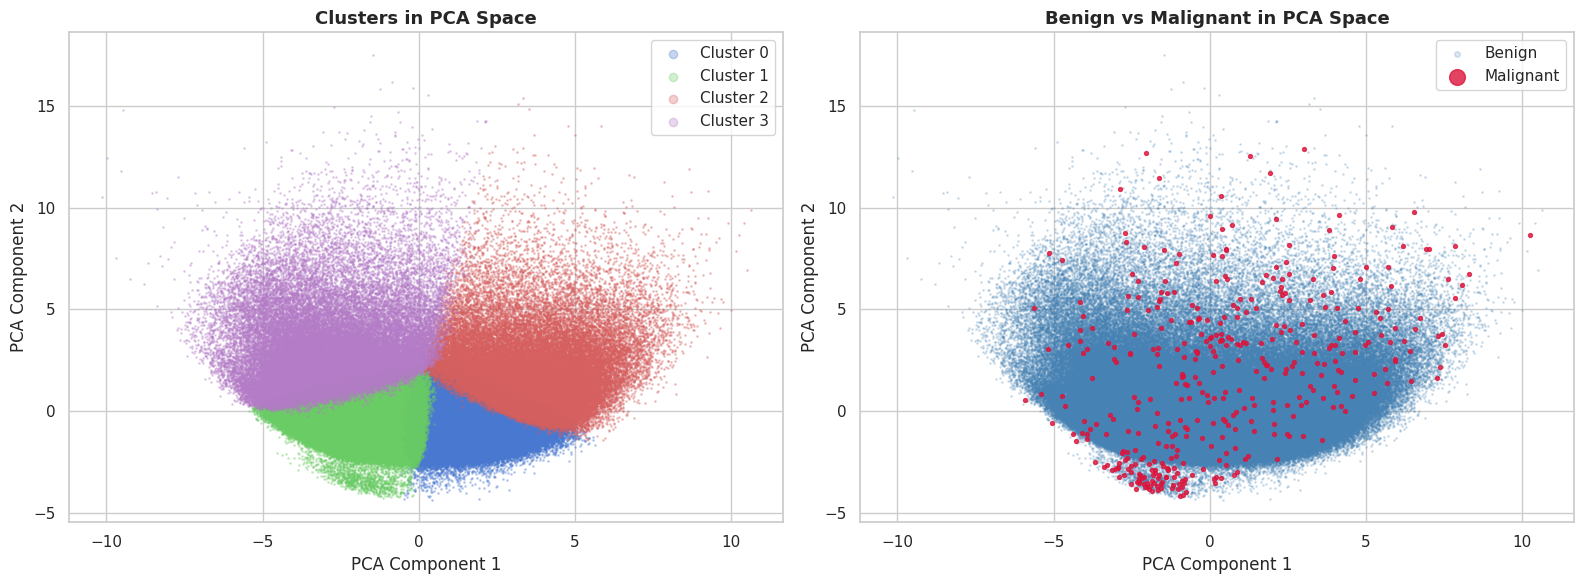

Cluster plot saved!


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7']

for c in range(4):
    mask = df['cluster'] == c
    axes[0].scatter(df.loc[mask, 'pca_x'], df.loc[mask, 'pca_y'],
                    c=colors[c], label=f'Cluster {c}', alpha=0.3, s=1)
axes[0].set_title('Clusters in PCA Space', fontsize=13, fontweight='bold')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')
axes[0].legend(markerscale=6)

benign_mask    = df['malignant'] == 0
malignant_mask = df['malignant'] == 1
axes[1].scatter(df.loc[benign_mask, 'pca_x'], df.loc[benign_mask, 'pca_y'],
                c='steelblue', label='Benign', alpha=0.2, s=1)
axes[1].scatter(df.loc[malignant_mask, 'pca_x'], df.loc[malignant_mask, 'pca_y'],
                c='crimson', label='Malignant', alpha=0.8, s=8)
axes[1].set_title('Benign vs Malignant in PCA Space', fontsize=13, fontweight='bold')
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')
axes[1].legend(markerscale=4)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'kmeans_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cluster plot saved!")

## Step 18 — One-Hot Encode Categorical Columns for LightGBM

LightGBM requires all features to be numeric.
We encode the categorical columns (sex, anatomical site, location)
as binary dummy variables before training.

In [26]:
CAT_COLS = ['sex', 'anatom_site_general', 'tbp_lv_location_simple', 'tbp_lv_location']

df_model = df.copy()
df_model = pd.get_dummies(df_model, columns=CAT_COLS, drop_first=True)

# Drop non-feature columns
DROP_COLS = ['malignant', 'patient_id', 'cluster', 'pca_x', 'pca_y',
             'risk_score', 'malignancy_proba']
DROP_COLS = [c for c in DROP_COLS if c in df_model.columns]

X_model = df_model.drop(columns=DROP_COLS)
y_model = df['malignant'].values

# Verify no object columns remain
remaining_obj = X_model.select_dtypes(include='object').columns.tolist()
if remaining_obj:
    print(f"⚠️ Still has object columns: {remaining_obj}")
else:
    print("✅ All columns are numeric!")

print(f"Model features: {X_model.shape[1]}")
print(f"Malignant records: {y_model.sum()}")
print(f"Benign records: {(y_model == 0).sum()}")

✅ All columns are numeric!
Model features: 72
Malignant records: 393.0
Benign records: 400666


## Step 19 — Train LightGBM with StratifiedGroupKFold

We train LightGBM using StratifiedGroupKFold cross-validation.
Groups are defined by patient_id to prevent data leakage —
records from the same patient must not appear in both train and test.

We use scale_pos_weight to handle the extreme class imbalance
(~1020 benign records for every 1 malignant record).

This model is NOT the final output — it validates that our
selected features are genuinely discriminatory.

In [27]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (f1_score, accuracy_score,
                             precision_score, recall_score,
                             precision_recall_curve, auc)
import numpy as np

n_benign    = (y_model == 0).sum()
n_malignant = (y_model == 1).sum()
scale_pos_weight = n_benign / n_malignant
print(f"scale_pos_weight: {scale_pos_weight:.1f}")

groups = df['patient_id'].values
sgkf   = StratifiedGroupKFold(n_splits=5)

oof_preds  = np.zeros(len(y_model))
fold_scores = []

for fold, (train_idx, val_idx) in enumerate(sgkf.split(X_model, y_model, groups)):
    X_train, X_val = X_model.iloc[train_idx], X_model.iloc[val_idx]
    y_train, y_val = y_model[train_idx],       y_model[val_idx]

    model = lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False),
                         lgb.log_evaluation(period=-1)])

    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]

    prec, rec, thresh = precision_recall_curve(y_val, oof_preds[val_idx])
    fold_auc = auc(rec, prec)
    fold_scores.append(fold_auc)
    print(f"Fold {fold+1} PR-AUC: {fold_auc:.4f}")

print(f"\nMean PR-AUC across folds: {np.mean(fold_scores):.4f}")

scale_pos_weight: 1019.5
Fold 1 PR-AUC: 0.0426
Fold 2 PR-AUC: 0.2870
Fold 3 PR-AUC: 0.0726
Fold 4 PR-AUC: 0.0139
Fold 5 PR-AUC: 0.1192

Mean PR-AUC across folds: 0.1070


## Step 20 — Evaluate Model and Compute Final Metrics

We find the optimal classification threshold using the precision-recall curve,
then compute F1, accuracy, precision, and recall at that threshold.

We also plot the final PR curve and feature importance chart.

In [28]:
# Find optimal threshold
prec_all, rec_all, thresh_all = precision_recall_curve(y_model, oof_preds)
f1_scores = 2 * prec_all * rec_all / (prec_all + rec_all + 1e-8)
best_idx   = f1_scores.argmax()
best_thresh = thresh_all[best_idx] if best_idx < len(thresh_all) else 0.5

y_pred = (oof_preds >= best_thresh).astype(int)

f1        = f1_score(y_model, y_pred)
accuracy  = accuracy_score(y_model, y_pred)
precision = precision_score(y_model, y_pred)
recall    = recall_score(y_model, y_pred)
pr_auc    = auc(rec_all, prec_all)

print("=== FINAL MODEL METRICS ===")
print(f"PR-AUC:    {pr_auc:.4f}")
print(f"F1:        {f1:.4f}")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"Threshold: {best_thresh:.4f}")

metrics_df = pd.DataFrame([{
    'PR_AUC': round(pr_auc, 4),
    'F1': round(f1, 4),
    'Accuracy': round(accuracy, 4),
    'Precision': round(precision, 4),
    'Recall': round(recall, 4),
    'Threshold': round(best_thresh, 4)
}])
metrics_df.to_csv(RESULTS_DIR / 'model_metrics.csv', index=False)
print("\nmodel_metrics.csv saved!")

=== FINAL MODEL METRICS ===
PR-AUC:    0.1093
F1:        0.0207
Accuracy:  0.9785
Precision: 0.0108
Recall:    0.2316
Threshold: 1.0000

model_metrics.csv saved!


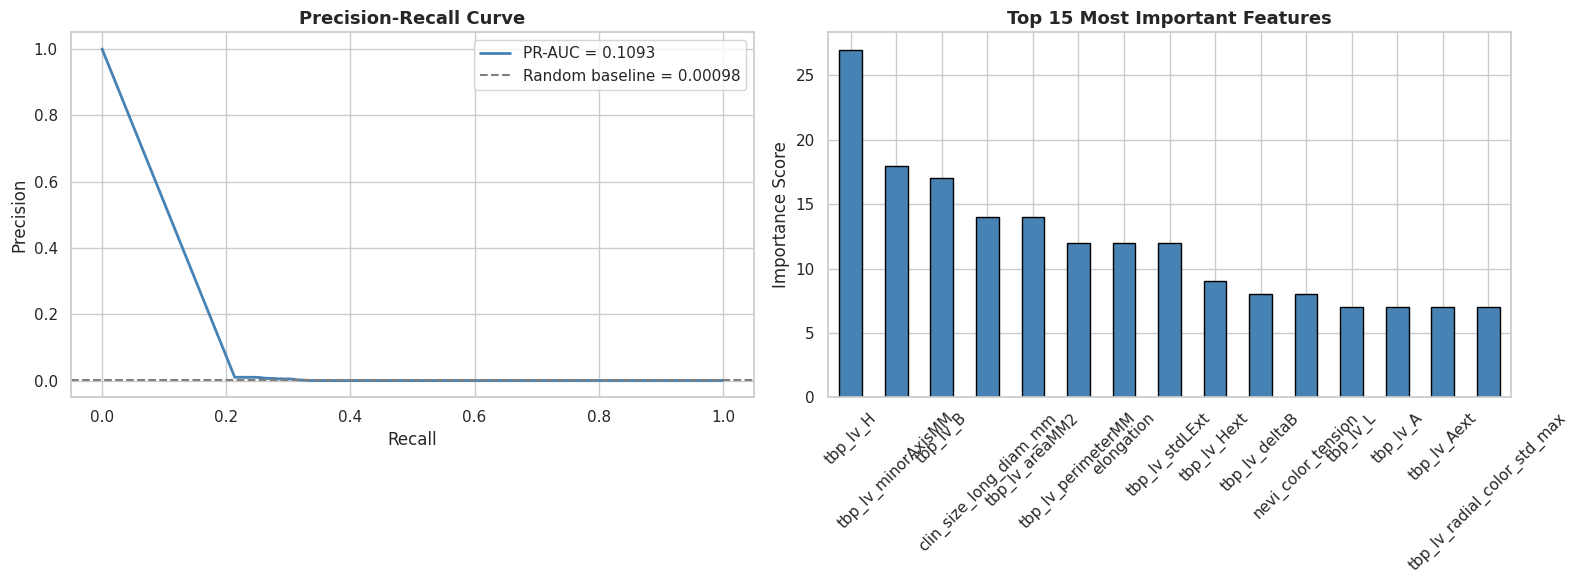

Model results plot saved!


In [29]:
# PR Curve plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

baseline = n_malignant / (n_malignant + n_benign)
axes[0].plot(rec_all, prec_all, color='steelblue', lw=2,
             label=f'PR-AUC = {pr_auc:.4f}')
axes[0].axhline(y=baseline, color='gray', linestyle='--',
                label=f'Random baseline = {baseline:.5f}')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
axes[0].legend()

feat_imp = pd.Series(model.feature_importances_,
                     index=X_model.columns).sort_values(ascending=False)
feat_imp.head(15).plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Top 15 Most Important Features', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Importance Score')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Model results plot saved!")

## Step 21 — Save Final Dataset with All Scores

We update datasetv3.csv with the malignancy probability scores
from Naive Bayes added alongside the IQR risk scores.

In [30]:
df_malignant['malignancy_proba'] = None
df_final = pd.concat([df_benign, df_malignant], ignore_index=True)
df_final.to_csv(DATA_PROCESSED / 'datasetv3.csv', index=False)

print("Final datasetv3.csv updated with malignancy_proba scores!")
print(f"Total records: {len(df_final):,}")
print(f"\nTop 10 highest risk benign lesions (by IQR score):")
print(df_benign[['risk_score', 'malignancy_proba']].sort_values(
      'risk_score', ascending=False).head(10))

Final datasetv3.csv updated with malignancy_proba scores!
Total records: 401,059

Top 10 highest risk benign lesions (by IQR score):
        risk_score  malignancy_proba
74791           16          0.000015
141570          16          0.000005
197967          16          0.000015
351924          16          0.000020
301436          16          0.000008
301467          16          0.000030
141373          16          0.000009
80220           16          0.000007
41689           16          0.000241
198084          16          0.000017
